# <center>Exploratory Data Analysis (EDA)</center>

## Table of Contents

- [Load Data](#Load-Data)
    - [Features](#Features)
    - [Train data](#Train-data)
    - [Test data](#Test-data)
    - [Social graph](#Social-graph)
- [Exploration Plan](#Exploration-Plan)
- [Baseline Statistics](#Baseline-Statistics)
    - [Feature profile](#Feature-profile)
    - [Dataset statistics](#Dataset-statistics)
- [Variable Inspection](#Variable-Inspection)
    - [`feature_001`](#feature_001)
    - [`feature_002`](#feature_002)
    - [`feature_003`](#feature_003)
    - [`feature_004`](#feature_004)
    - [`feature_005`](#feature_005)
    - [`feature_006`](#feature_006)
    - [`feature_007`](#feature_007)
    - [`feature_008`](#feature_008)
    - [`feature_009`](#feature_009)
    - [`feature_010`](#feature_010)
    - [`feature_011`](#feature_011)
    - [`feature_012`](#feature_012)
    - [`feature_013`](#feature_013)
    - [`feature_014`](#feature_014)
    - [`feature_015`](#feature_015)
    - [`feature_016`](#feature_016)
    - [`feature_017`](#feature_017)
    - [`feature_018`](#feature_018)
    - [Conclusion](#Conclusion)
- [Duplicates](#Duplicates)
- [Missing Values](#Missing-Values)
    - [Imputation considerations](#Imputation-considerations)
- [Outliers](#Outliers)
- [Relationships](#Relationships)
    - [Numerical-numerical relationships](#Numerical-numerical-relationships)
    - [Categorical-categorical relationships](#Categorical-categorical-relationships)
    - [Mixed-variable relationships](#Mixed-variable-relationships)
    - [Feature-target and feature-flagging relationships](#Feature-target-and-feature-flagging-relationships)
- [Sampling Bias](#Sampling-Bias)
    - [Evidence for sampling bias](#Evidence-for-sampling-bias)
    - [Addressing sampling bias](#Evidence-for-sampling-bias)
- [Class Imbalance](#Class-Imbalance)
    - [Evidence for class imbalance](#Evidence-for-class-imbalance)
    - [Addressing class imbalance](#Evidence-for-class-imbalance)
- [Social Graph Analysis](#Social-Graph-Analysis)
    - [Repeated edges](#Repeated-edges)
    - [Out-degree analysis](#Out-degree-analysis)
    - [In-degree analysis](#In-degree-analysis)
    - [Connected components](#Connected-components)

## Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Features

In [2]:
import json

feature_metadata_path = "../data/feature_metadata.json"
with open(feature_metadata_path) as f:
    feature_metadata = json.load(f)
feature_metadata

{'feature_001': {'type': 'numeric', 'range': '1-5', 'missing_%': 11.9},
 'feature_002': {'type': 'numeric', 'range': '1-10', 'missing_%': 11.7},
 'feature_003': {'type': 'numeric', 'range': '1-10', 'missing_%': 11.7},
 'feature_004': {'type': 'numeric', 'range': '0-10', 'missing_%': 0.9},
 'feature_005': {'type': 'numeric', 'range': '1-10', 'missing_%': 2.1},
 'feature_006': {'type': 'numeric', 'range': '0-10', 'missing_%': 0.9},
 'feature_007': {'type': 'binary', 'range': '0-1', 'missing_%': 2.6},
 'feature_008': {'type': 'numeric', 'range': '0-10', 'missing_%': 2.7},
 'feature_009': {'type': 'numeric', 'range': '0-10', 'missing_%': 2.7},
 'feature_010': {'type': 'numeric', 'range': '0-39128914', 'missing_%': 2.7},
 'feature_011': {'type': 'binary', 'range': '0-1', 'missing_%': 2.6},
 'feature_012': {'type': 'numeric', 'range': '0-3', 'missing_%': 4.6},
 'feature_013': {'type': 'binary', 'range': '0-1', 'missing_%': 2.6},
 'feature_014': {'type': 'binary', 'range': '0-1', 'missing_%':

In [3]:
feature_names = list(feature_metadata.keys())

### Train data

In [4]:
import pandas as pd

data_train_path = "../data/train.csv"
data_train = pd.read_csv(data_train_path)
data_train.head()

,user_hash,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,...,feature_011,feature_012,feature_013,feature_014,feature_015,feature_016,feature_017,feature_018,high_conf_clean,is_cheating
0,680f47f06ba8f132,1.0,6.0,7.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.029190,1,0.133333,0.7500,1.0,NaN
1,dbf485f686e509c6,NaN,NaN,NaN,3.0,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,101.339549,1,5.466667,NaN,NaN,1.0
2,b49927482049a4ea,1.0,2.0,9.0,1.0,1.0,6.0,1.0,0.0,0.0,...,0.0,2.0,1.0,1.0,37.091111,3,8.003991,0.7975,1.0,NaN
3,334d8c0aca4b2fd9,3.0,7.0,6.0,2.0,8.0,6.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.049236,2,21.691667,0.7500,1.0,NaN
4,363d12825b7b131a,1.0,2.0,6.0,1.0,4.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.048692,1,13.316667,0.6100,1.0,NaN


In [5]:
data_train.shape

(272819, 21)

In [6]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 272819 entries, 0 to 272818
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   user_hash        272819 non-null  str    
 1   feature_001      240704 non-null  float64
 2   feature_002      241114 non-null  float64
 3   feature_003      241114 non-null  float64
 4   feature_004      270420 non-null  float64
 5   feature_005      267020 non-null  float64
 6   feature_006      270605 non-null  float64
 7   feature_007      266984 non-null  float64
 8   feature_008      266723 non-null  float64
 9   feature_009      266723 non-null  float64
 10  feature_010      266723 non-null  float64
 11  feature_011      267003 non-null  float64
 12  feature_012      261527 non-null  float64
 13  feature_013      267003 non-null  float64
 14  feature_014      266939 non-null  float64
 15  feature_015      272819 non-null  float64
 16  feature_016      272819 non-null  int64  
 17  fe

In [7]:
data_train["user_hash"].nunique() == len(data_train)

True

**NOTE** `user_hash` is confirmed a unique identifier, not a predictive feature, so it's excluded from the feature list.

In [8]:
target_name = "is_cheating"
feature_names = feature_names + ["high_conf_clean"]
features_train, target_train = data_train[feature_names], data_train[target_name]

In [9]:
# Sanity check.
(data_train["high_conf_clean"].notna() ^ data_train["is_cheating"].notna()).all()

np.True_

### Test data

In [10]:
data_test_path = "../data/test.csv"
data_test = pd.read_csv(data_test_path)
data_test.head()

,user_hash,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,feature_010,feature_011,feature_012,feature_013,feature_014,feature_015,feature_016,feature_017,feature_018
0,33915f8c9f1ff891,5.0,6.0,1.0,9.0,8.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,1.0,0.0,0.043113,2,15.850000,0.094450
1,9b6216bf06fcf724,5.0,9.0,5.0,1.0,1.0,0.0,1.0,9.0,0.0,1026.0,0.0,0.0,0.0,0.0,512.289769,0,NaN,NaN
2,7d8c9db1fc22bb6b,5.0,2.0,3.0,7.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.031331,1,11.533333,0.400000
3,aa231cad06c66ab1,5.0,8.0,3.0,1.0,1.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.016042,0,NaN,0.655556
4,bc41e60a4ff49aa5,5.0,8.0,3.0,9.0,6.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.042616,2,11.858333,0.400000


In [11]:
data_test.shape

(48416, 19)

In [12]:
data_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 48416 entries, 0 to 48415
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_hash    48416 non-null  str    
 1   feature_001  42428 non-null  float64
 2   feature_002  42530 non-null  float64
 3   feature_003  42530 non-null  float64
 4   feature_004  47887 non-null  float64
 5   feature_005  47471 non-null  float64
 6   feature_006  47599 non-null  float64
 7   feature_007  45955 non-null  float64
 8   feature_008  45889 non-null  float64
 9   feature_009  45889 non-null  float64
 10  feature_010  45889 non-null  float64
 11  feature_011  45964 non-null  float64
 12  feature_012  45030 non-null  float64
 13  feature_013  45964 non-null  float64
 14  feature_014  45939 non-null  float64
 15  feature_015  48416 non-null  float64
 16  feature_016  48416 non-null  int64  
 17  feature_017  42184 non-null  float64
 18  feature_018  41065 non-null  float64
dtypes: float64(17),

### Social graph

In [13]:
social_graph_path = "../data/social_graph.csv"
social_graph = pd.read_csv(social_graph_path)
social_graph.head()

,user_a,user_b
0,498ddae773657c1a,5d4b7200846c75f7
1,498ddae773657c1a,eb655ccaaf1709d3
2,c2c37e73440ecc45,0593ce961c3e1a9b
3,83411c422e8391fd,9ffb4076e4256600
4,307c907a33eca2e8,7e74f7bd16f33e2e


In [14]:
social_graph.shape

(1714763, 2)

In [15]:
graph_users = set(social_graph["user_a"]) | set(social_graph["user_b"])
graph_edges = set(zip(social_graph["user_a"], social_graph["user_b"]))

data_train_in_graph = data_train[data_train["user_hash"].isin(graph_users)]
target_train_in_graph = target_train[data_train["user_hash"].isin(graph_users)]

In [16]:
data_test["user_hash"].isin(graph_users).value_counts(normalize=True)

user_hash
True     0.731927
False    0.268073
Name: proportion, dtype: float64

**NOTE** Test users are also part of the social graph.

In [17]:
# Reverse-pair overlap check.
reversed_edges = set(zip(social_graph["user_b"], social_graph["user_a"]))
overlap = graph_edges & reversed_edges
len(overlap)

1312

In [18]:
# Duplicate count check.
social_graph.duplicated(subset=["user_a", "user_b"]).sum()

np.int64(4313)

**NOTE** The tiny reverse-pair overlap (1,312) and duplicate count (4,313) are inconclusive, since the duplicates suggest data noise that weakens any evidence for directionality. However, Mercor's [external contest listing](https://work.mercor.com/jobs/list_AAABmuZ8XM29hAHcM8NNgLXq/mercor-cheating-detection-kaggle-contest) explicitly calls this a **referral** graph, which is directed by nature.

## Exploration Plan

**NOTE** Exploratory data analysis should be performed exclusively on the training data to avoid any risk of leakage from the test set. We adhere to this restriction except for basic structural checks on test data that do not inform our modeling decisions.

We outline our exploration plan below.

- **Gather baseline statistics.** Examine row counts, label distribution (positive/negative/unlabeled), and social-graph coverage overall and by label status to establish the basic structure and coverage of the dataset.
- **Examine the variables.** We will examine the variables for format, encoding, value ranges, distributions, relationships with the target, and differences between flagged and unflagged candidates.
- **Check for duplicates.** We will verify that `user_hash` uniquely identifies users in the main dataset and remove duplicate user records if present.
- **Investigate missing values.** We will examine the extent of missing values across variables, and investigate their patterns before deciding how to handle them.
- **Identify outliers.** We will investigate potential outliers and decide how to handle them based on their characteristics.
- **Explore relationships.** We will examine correlations among features to identify potentially redundant variables and notable dependencies.
- **Investigate sampling bias.** We will compare labeled and unlabeled populations to identify systematic differences in their feature distributions and other characteristics.
- **Assess class imbalance.** We will examine the balance between positive and negative labels and consider its implications for subsequent modeling.
- **Analyze the social graph.** We will examine its structure, coverage, and potential duplicate entries, and determine how these characteristics may affect its use as a source of features or labels.

## Baseline Statistics

### Feature profile 

In [19]:
features_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 272819 entries, 0 to 272818
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   feature_001      240704 non-null  float64
 1   feature_002      241114 non-null  float64
 2   feature_003      241114 non-null  float64
 3   feature_004      270420 non-null  float64
 4   feature_005      267020 non-null  float64
 5   feature_006      270605 non-null  float64
 6   feature_007      266984 non-null  float64
 7   feature_008      266723 non-null  float64
 8   feature_009      266723 non-null  float64
 9   feature_010      266723 non-null  float64
 10  feature_011      267003 non-null  float64
 11  feature_012      261527 non-null  float64
 12  feature_013      267003 non-null  float64
 13  feature_014      266939 non-null  float64
 14  feature_015      272819 non-null  float64
 15  feature_016      272819 non-null  int64  
 16  feature_017      244050 non-null  float64
 17  fe

In [20]:
def summarize_features(df, feature_metadata):
    for feature, meta in feature_metadata.items():
        values = df[feature].dropna()
        unique_values = sorted(values.unique())
        missing_pct = df[feature].isna().mean() * 100

        if meta["type"] == "binary":
            value_str = "0, 1 (binary)"
        elif len(unique_values) > 15:
            value_str = f"{unique_values[0]:g}, {unique_values[1]:g}, ..., {unique_values[-1]:g}"
        else:
            value_str = ", ".join(f"{v:g}" for v in unique_values)

        print(f"{feature}: {value_str:<40} [{missing_pct:>5.1f}% missing]")

In [21]:
summarize_features(features_train, feature_metadata)

feature_001: 1, 2, 3, 4, 5                            [ 11.8% missing]
feature_002: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10            [ 11.6% missing]
feature_003: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10            [ 11.6% missing]
feature_004: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10         [  0.9% missing]
feature_005: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10            [  2.1% missing]
feature_006: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10         [  0.8% missing]
feature_007: 0, 1 (binary)                            [  2.1% missing]
feature_008: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10         [  2.2% missing]
feature_009: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10         [  2.2% missing]
feature_010: 0, 1, ..., 3.91289e+07                   [  2.2% missing]
feature_011: 0, 1 (binary)                            [  2.1% missing]
feature_012: 0, 1, 2, 3                               [  4.1% missing]
feature_013: 0, 1 (binary)                            [  2.1% missing]
feature_014: 0, 1 (binary)                            [  2.2% missing]
featur

**Quick Observations:**
- Most features are categorical (small discrete ranges), with a few numerical exceptions.
- Missing rates are broadly similar between train and test, although some features show noticeable differences.
- Several features share identical missing rates and similar value ranges (e.g. `feature_002/003` and `feature_008/009`), while `feature_008/009/010` also share similar missingness. It is worth checking whether these features are missing on the exact same rows and investigating whether any are duplicates or otherwise related.
- No feature is missing more than \~12% of its values, which is a useful baseline fact.
- `feature_015` and `feature_016` are the only features with zero missing values.
- `feature_010` has a range (0 to \~39M) that is dramatically larger than that of the other features, and its scale warrants further investigation.

### Dataset statistics

In [22]:
def label_status(labels):
    return np.select(
        [labels == 1.0, labels == 0.0, labels.isna()],
        ["Positive", "Negative", "Unlabeled"],
        default="Unknown",
    )


def label_graph_summary_table(df, graph_users):
    status = pd.Series(
        label_status(df["is_cheating"]),
        index=df.index,
        name="Label",
    )
    in_graph = df["user_hash"].isin(graph_users).map(
        {True: "In graph", False: "Outside graph"}
    )
    in_graph.name = "Graph"

    counts = pd.crosstab(status, in_graph, margins=True, margins_name="Total")
    counts.loc["Labeled"] = counts.loc["Positive"] + counts.loc["Negative"]
    counts = counts.reindex(["Positive", "Negative", "Labeled", "Unlabeled", "Total"])
    counts = counts.rename_axis(index=None, columns=None)

    percentages = (counts / counts.loc["Total", "Total"] * 100).round(2)
    return counts.astype(str) + " (" + percentages.astype(str) + "%)"


def graph_coverage_table(df, graph_users):
    in_graph = df["user_hash"].isin(graph_users)
    counts = pd.Series(
        {"In graph": in_graph.sum(), "Outside graph": (~in_graph).sum()}
    )
    counts["Total"] = counts.sum()

    percentages = (counts / counts["Total"] * 100).round(2)
    return counts.astype(str) + " (" + percentages.astype(str) + "%)"

In [23]:
print("Train:\n" + "-" * 50)
label_graph_summary_table(data_train, graph_users)

Train:
--------------------------------------------------


,In graph,Outside graph,Total
Positive,22049 (8.08%),12382 (4.54%),34431 (12.62%)
Negative,60104 (22.03%),18431 (6.76%),78535 (28.79%)
Labeled,82153 (30.11%),30813 (11.29%),112966 (41.41%)
Unlabeled,115767 (42.43%),44086 (16.16%),159853 (58.59%)
Total,197920 (72.55%),74899 (27.45%),272819 (100.0%)


In [24]:
print("Test:\n" + "-" * 50)
graph_coverage_table(data_test, graph_users)

Test:
--------------------------------------------------


In graph         35437 (73.19%)
Outside graph    12979 (26.81%)
Total            48416 (100.0%)
dtype: str

**Quick Observations:**
- Most examples are unlabeled.
- There is class imbalance among labeled examples, roughly 1:2.3 in favor of negative (non-cheating) examples.
- Graph coverage is fairly high overall (\~72%), but varies by label status: positive examples have lower coverage (\~64%) than negative (\~76.5%) or unlabeled (\~72.4%) examples.
- Class imbalance is less severe outside the graph (\~1:1.5) than inside it (\~1:2.7), with positive examples proportionally overrepresented outside the graph.
- Test-set graph coverage (\~73.2%) is very close to train-set coverage (\~72.6%), suggesting no major difference in graph presence between the two sets.

## Variable Inspection

In [25]:
variable_names = feature_names + [target_name]
data_train[variable_names].info()

<class 'pandas.DataFrame'>
RangeIndex: 272819 entries, 0 to 272818
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   feature_001      240704 non-null  float64
 1   feature_002      241114 non-null  float64
 2   feature_003      241114 non-null  float64
 3   feature_004      270420 non-null  float64
 4   feature_005      267020 non-null  float64
 5   feature_006      270605 non-null  float64
 6   feature_007      266984 non-null  float64
 7   feature_008      266723 non-null  float64
 8   feature_009      266723 non-null  float64
 9   feature_010      266723 non-null  float64
 10  feature_011      267003 non-null  float64
 11  feature_012      261527 non-null  float64
 12  feature_013      267003 non-null  float64
 13  feature_014      266939 non-null  float64
 14  feature_015      272819 non-null  float64
 15  feature_016      272819 non-null  int64  
 16  feature_017      244050 non-null  float64
 17  fe

In [26]:
data_train[variable_names].head(10)

,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,feature_010,feature_011,feature_012,feature_013,feature_014,feature_015,feature_016,feature_017,feature_018,high_conf_clean,is_cheating
0,1.0,6.0,7.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.029190,1,0.133333,0.7500,1.0,NaN
1,NaN,NaN,NaN,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.339549,1,5.466667,NaN,NaN,1.0
2,1.0,2.0,9.0,1.0,1.0,6.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,37.091111,3,8.003991,0.7975,1.0,NaN
3,3.0,7.0,6.0,2.0,8.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.049236,2,21.691667,0.7500,1.0,NaN
4,1.0,2.0,6.0,1.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.048692,1,13.316667,0.6100,1.0,NaN
5,1.0,2.0,4.0,5.0,6.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,11.218252,1,21.933333,0.8500,1.0,NaN
6,1.0,2.0,7.0,1.0,5.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,16.980081,2,3.983333,0.7500,1.0,NaN
7,1.0,2.0,8.0,8.0,3.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.090729,3,18.316710,0.5100,1.0,NaN
8,NaN,NaN,NaN,6.0,10.0,0.0,1.0,8.0,0.0,1300.0,0.0,0.0,0.0,0.0,0.076794,4,7.987882,0.7000,NaN,0.0
9,1.0,2.0,8.0,9.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.067535,3,14.176900,0.8250,1.0,NaN


In [27]:
data_train[variable_names].describe()

,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,feature_010,feature_011,feature_012,feature_013,feature_014,feature_015,feature_016,feature_017,feature_018,high_conf_clean,is_cheating
count,240704.000000,241114.000000,241114.000000,270420.000000,267020.000000,270605.000000,266984.000000,266723.000000,266723.000000,2.667230e+05,267003.000000,261527.000000,267003.000000,266939.000000,272819.000000,272819.000000,244050.000000,245184.000000,159853.0,112966.000000
mean,2.981646,4.256601,6.225640,5.102489,4.376972,4.439282,0.925557,3.630756,2.439640,8.090543e+02,0.010307,0.317428,0.540335,0.834101,25.108919,2.778905,13.805947,0.574001,1.0,0.304791
std,1.637483,2.677252,1.965926,3.687220,2.713772,3.018614,0.262490,4.011704,3.961549,7.735875e+04,0.100999,0.738072,0.498371,0.371991,72.878142,6.418794,6.145651,0.226960,0.0,0.460321
min,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-7.008252,0.000000,0.000000,0.000000,1.0,0.000000
25%,1.000000,2.000000,5.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,0.039606,1.000000,9.616667,0.425000,1.0,0.000000
50%,4.000000,3.000000,6.000000,6.000000,3.000000,6.000000,1.000000,1.000000,0.000000,3.000000e+00,0.000000,0.000000,1.000000,1.000000,0.705370,1.000000,14.650000,0.600000,1.0,0.000000
75%,4.000000,7.000000,8.000000,9.000000,7.000000,7.000000,1.000000,9.000000,8.000000,5.050000e+02,0.000000,0.000000,1.000000,1.000000,13.845544,2.000000,18.695121,0.750000,1.0,1.000000
max,5.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,10.000000,10.000000,3.912891e+07,1.000000,3.000000,1.000000,1.000000,897.850613,581.000000,24.000000,1.000000,1.0,1.000000


**Quick Overview.**
- `feature_001` is a categorical variable with 5 observed levels (1–5).
- `feature_002` is a categorical variable with 10 observed levels (1–10).
- `feature_003` is a categorical variable with 10 observed levels (1–10).
- `feature_004` is a categorical variable with 11 observed levels (0–10).
- `feature_005` is a categorical variable with 10 observed levels (1–10).
- `feature_006` is a categorical variable with 11 observed levels (0–10).
- `feature_007` is a binary variable with two observed values (0 and 1).
- `feature_008` is a categorical variable with 11 observed levels (0–10).
- `feature_009` is a categorical variable with 11 observed levels (0–10).
- `feature_010` is a non-negative numerical variable ranging from 0 to approximately 39.1 million.
- `feature_011` is a binary variable with two observed values (0 and 1).
- `feature_012` is a categorical variable with 4 observed levels (0-3).
- `feature_013` is a binary variable with two observed values (0 and 1).
- `feature_014` is a binary variable with two observed values (0 and 1).
- `feature_015` is a numerical variable ranging from approximately −7 to 898.
- `feature_016` is a non-negative integer variable ranging from 0 to 581.
- `feature_017` is a numerical variable ranging from 0 to 24.
- `feature_018` is a numerical variable ranging from 0 to 1.
- `high_conf_clean` is a flag variable with a single observed value (1), applicable only to unlabeled examples.
- `is_cheating` is the target variable, a binary variable with two observed values (0 and 1).

In [28]:
categorical_features = [
    "feature_001", "feature_002", "feature_003", "feature_004",
    "feature_005", "feature_006", "feature_007", "feature_008",
    "feature_009", "feature_011", "feature_012", "feature_013",
    "feature_014",
]

numerical_features = ["feature_010", "feature_015", "feature_016", "feature_017", "feature_018"]

features = categorical_features + numerical_features

**Two views of feature-target relationships.** Throughout this section, two views are presented for each feature. Both are affected by the mechanism that determines which candidates are flagged for review:
- **Labeled view:** shows the feature's relationship with `is_cheating` among manually reviewed (labeled) candidates.
- **Unflagged view:** shows the feature's distribution among candidates with `high_conf_clean = 1` (not flagged for review).

In [29]:
data_train_unflagged = data_train[data_train["high_conf_clean"] == 1]

**Helper Functions:**

In [30]:
def value_distribution(df, feature_name):
    counts = df[feature_name].value_counts(dropna=False)
    counts.index = counts.index.map(
        lambda x: "Missing" if pd.isna(x) else x
    )
    counts = counts.sort_index(
        key=lambda idx: idx.map(
            lambda x: (x == "Missing", x if x != "Missing" else 0)
        )
    )
    percentages = counts / counts.sum() * 100
    formatted_counts = counts.astype(str).str.rjust(6)
    formatted_percentages = percentages.map(lambda x: f"{x:5.2f}")
    return formatted_counts + " (" + formatted_percentages + "%)"

In [31]:
def countplot_with_pct(ax, data, x, hue=None):
    sns.countplot(data=data, x=x, hue=hue, ax=ax)
    total = data[x].notna().sum()
    for bar in ax.patches:
        count = bar.get_height()
        if count == 0:
            continue
        ax.annotate(
            f"{count / total:.1%}",
            (bar.get_x() + bar.get_width() / 2, count),
            ha="center",
            va="bottom",
        )
    ax.margins(y=0.15)

In [32]:
def plot_categorical_histogram(df, feature_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    countplot_with_pct(ax, df, feature_name)
    ax.set_title(f"Histogram of {feature_name}")

    return fig, ax


def plot_categorical_target_relationship(df, feature_name, target, ax=None):
    target_name = target.name
    mask = target.notna()
    labeled = df[mask].copy()
    labeled[target_name] = target[mask]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    countplot_with_pct(ax, labeled, feature_name, hue=target_name)
    ax.set_title(f"{feature_name} by {target_name}")

    return fig, ax


def plot_categorical_labeled_view(df, feature_name, target):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_categorical_histogram(df, feature_name, ax=axes[0])
    plot_categorical_target_relationship(df, feature_name, target, ax=axes[1])
    plt.tight_layout()
    plt.show()


def plot_categorical_unflagged_view(df, unflagged_df, feature_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_categorical_histogram(df, feature_name, ax=axes[0])
    plot_categorical_histogram(unflagged_df, feature_name, ax=axes[1])
    axes[1].set_title(axes[1].get_title() + " (Unflagged)")
    plt.tight_layout()
    plt.show()

In [33]:
def plot_numerical_histogram(df, feature_name, bins=50, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure
    x = df[feature_name].dropna()
    ax.hist(x, bins=bins)
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Count")
    ax.set_title(f"Histogram of {feature_name}")
    return fig, ax

def plot_numerical_target_relationship(df, feature_name, target, bins=50, ax=None):
    target_name = target.name
    mask = target.notna()

    x_negative = df.loc[mask & (target == 0), feature_name].dropna()
    x_positive = df.loc[mask & (target == 1), feature_name].dropna()

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    ax.hist(x_negative, bins=bins, alpha=0.5, label="Negative")
    ax.hist(x_positive, bins=bins, alpha=0.5, label="Positive")
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Count")
    ax.set_title(f"{feature_name} by {target_name}")
    ax.legend()
    return fig, ax


def plot_numerical_labeled_view(df, feature_name, target, bins=50):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_numerical_histogram(df, feature_name, bins=bins, ax=axes[0])
    plot_numerical_target_relationship(df, feature_name, target, bins=bins, ax=axes[1])
    plt.tight_layout()
    plt.show()


def plot_numerical_unflagged_view(df, unflagged_df, feature_name, bins=50):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_numerical_histogram(df, feature_name, bins=bins, ax=axes[0])
    plot_numerical_histogram(unflagged_df, feature_name, bins=bins, ax=axes[1])
    axes[1].set_title(axes[1].get_title() + " (Unflagged)")
    plt.tight_layout()
    plt.show()

In [34]:
def log_transform_and_plot(df, feature_name, target):
    log_name = f"log_{feature_name}"
    log_values = np.log1p(df[feature_name] - df[feature_name].min())
    df_log = df.assign(**{log_name: log_values})
    plot_numerical_labeled_view(df_log, log_name, target)
    return log_values


def binned_positive_rate(log_values, target, bins=10):
    mask = target.notna()
    binned = pd.cut(log_values[mask], bins=bins)
    counts = pd.crosstab(binned, target[mask])
    rates = pd.crosstab(binned, target[mask], normalize="index").round(3)
    summary = counts.copy()
    summary["Positive Rate"] = (rates[1.0] * 100).round(1).astype(str) + "%"
    return summary

### `feature_001`

In [35]:
value_distribution(data_train, "feature_001")

feature_001
1.0         84917 (31.13%)
2.0         16242 ( 5.95%)
3.0         11848 ( 4.34%)
4.0         73736 (27.03%)
5.0         53961 (19.78%)
Missing     32115 (11.77%)
Name: count, dtype: str

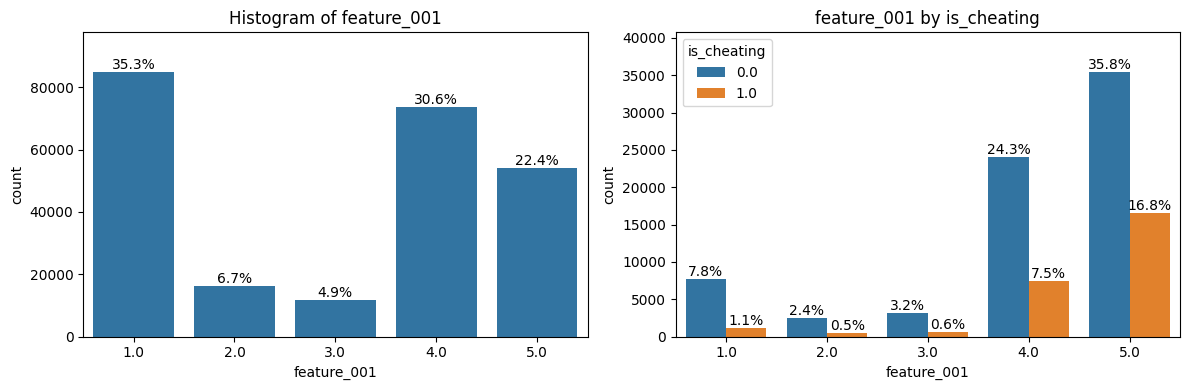

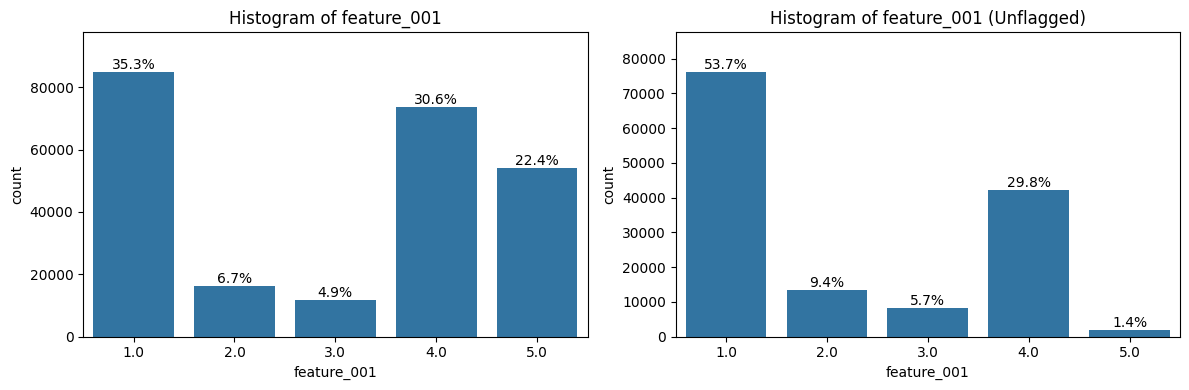

In [36]:
plot_categorical_labeled_view(data_train, "feature_001", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_001")

**Discussion.** The labeled view shows differences in the Positive rate across levels of `feature_001`: level 1 candidates are mostly Negative when reviewed, while level 5 candidates have a higher Positive rate. The unflagged view is different, with level 1 overrepresented and level 5 almost absent. Together, these views show that `feature_001` is associated with both the cheating status of reviewed candidates and the probability of being flagged.

### `feature_002`

In [37]:
value_distribution(data_train, "feature_002")

feature_002
1.0          9748 ( 3.57%)
2.0        102656 (37.63%)
3.0         23897 ( 8.76%)
4.0          8709 ( 3.19%)
5.0         11810 ( 4.33%)
6.0         11019 ( 4.04%)
7.0         25751 ( 9.44%)
8.0         29238 (10.72%)
9.0         17446 ( 6.39%)
10.0          840 ( 0.31%)
Missing     31705 (11.62%)
Name: count, dtype: str

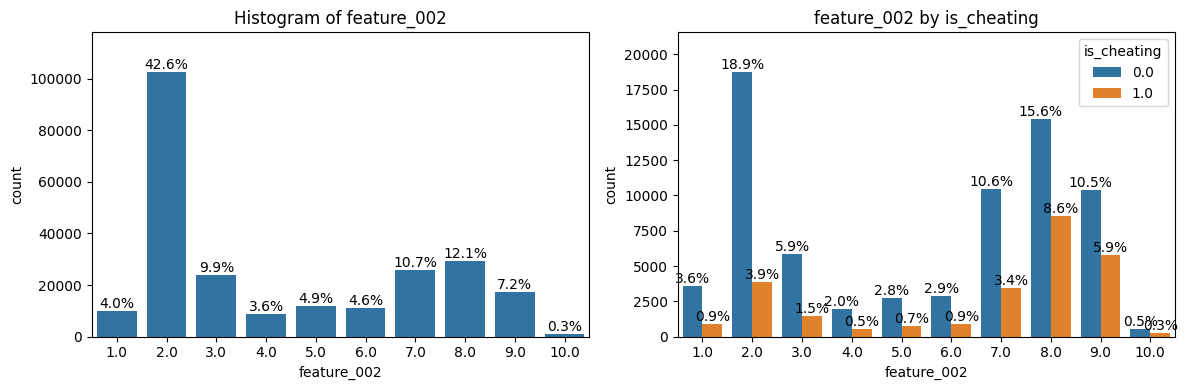

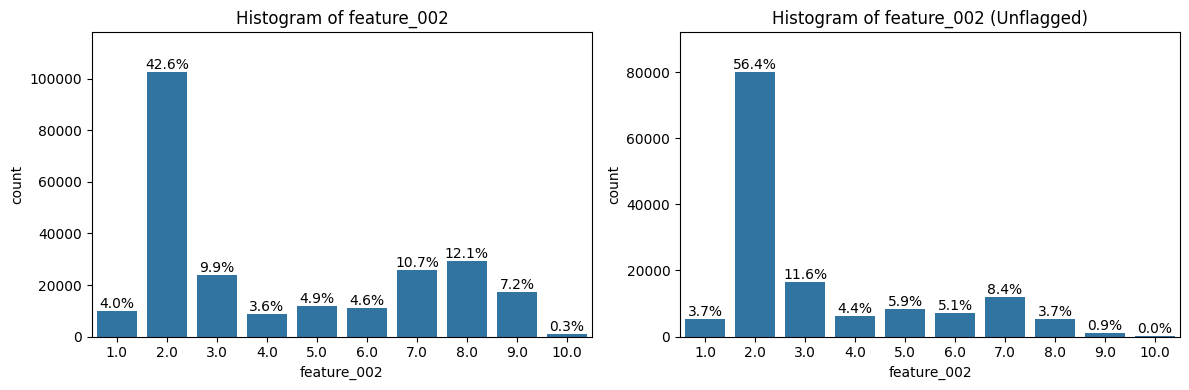

In [38]:
plot_categorical_labeled_view(data_train, "feature_002", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_002")

**Discussion.** The unflagged view shows that levels 7–9 are less common among unflagged candidates than in the full distribution, suggesting that these levels are more likely to be flagged for review. Among reviewed candidates, however, their Positive rates are not notably higher than for the other levels. This suggests that `feature_002` is more closely related to the probability of being flagged than to the cheating status of reviewed candidates.

### `feature_003`

In [39]:
value_distribution(data_train, "feature_003")

feature_003
1.0          4202 ( 1.54%)
2.0          5855 ( 2.15%)
3.0         15227 ( 5.58%)
4.0         26042 ( 9.55%)
5.0         26578 ( 9.74%)
6.0         42768 (15.68%)
7.0         42100 (15.43%)
8.0         54042 (19.81%)
9.0         24206 ( 8.87%)
10.0           94 ( 0.03%)
Missing     31705 (11.62%)
Name: count, dtype: str

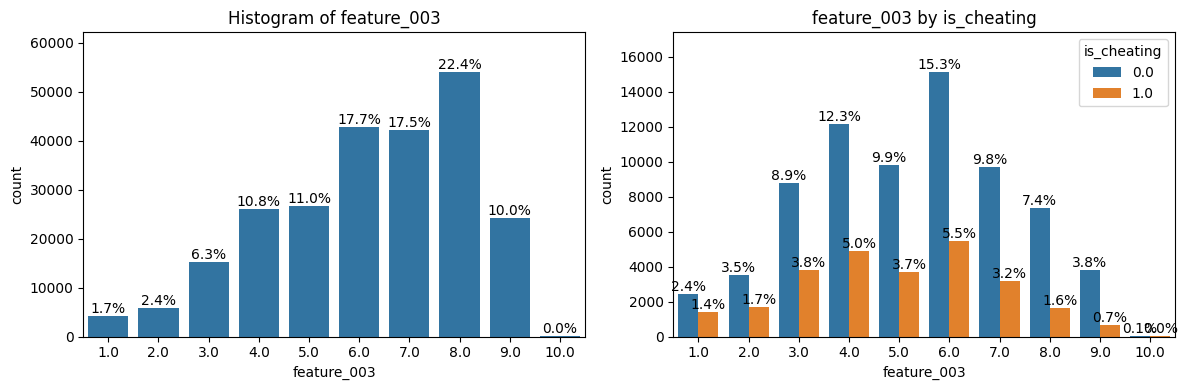

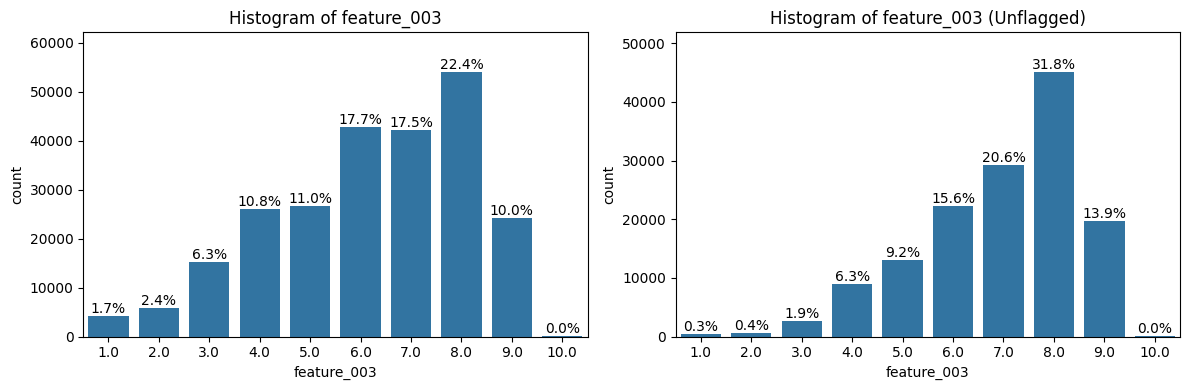

In [40]:
plot_categorical_labeled_view(data_train, "feature_003", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_003")

**Discussion.** No clear relationship with either the cheating status of reviewed candidates or the probability of being flagged is apparent for `feature_003`.

### `feature_004`

In [41]:
value_distribution(data_train, "feature_004")

feature_004
0.0             1 ( 0.00%)
1.0        102420 (37.54%)
2.0         14631 ( 5.36%)
3.0          5300 ( 1.94%)
4.0          1701 ( 0.62%)
5.0          4074 ( 1.49%)
6.0          8011 ( 2.94%)
7.0         21473 ( 7.87%)
8.0         32283 (11.83%)
9.0         56842 (20.84%)
10.0        23684 ( 8.68%)
Missing      2399 ( 0.88%)
Name: count, dtype: str

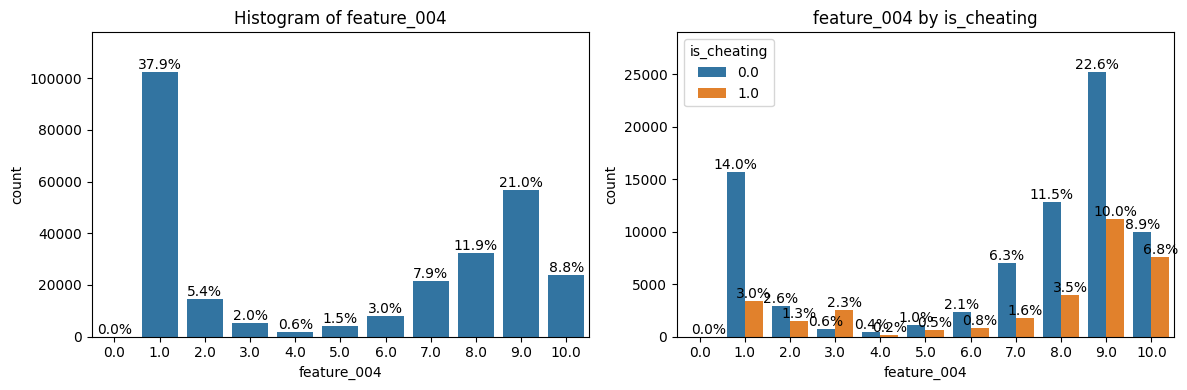

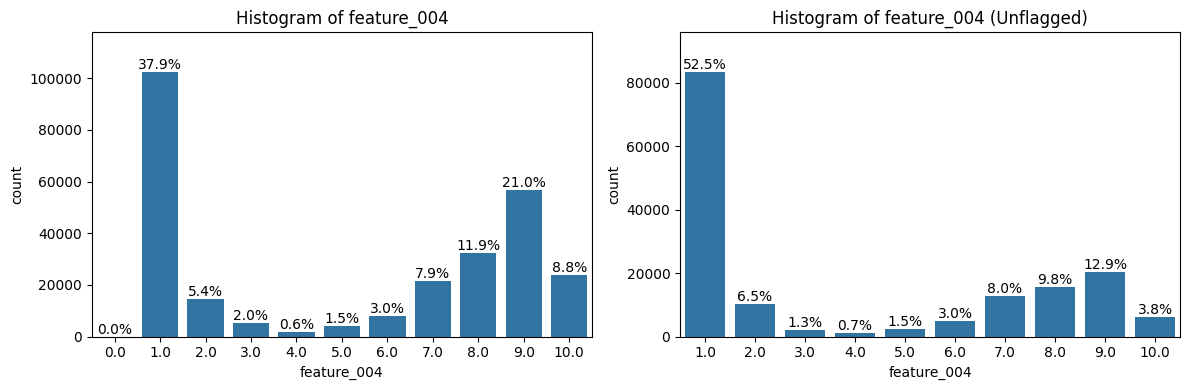

In [42]:
plot_categorical_labeled_view(data_train, "feature_004", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_004")

**Discussion.** `feature_004` shows a clear pattern. Level 1 is strongly overrepresented among unflagged candidates and, when reviewed, is mostly Negative (\~18% Positive rate). Level 10 is underrepresented among unflagged candidates relative to its overall share, meaning it is more likely to be flagged for review. Level 3 stands out further: despite a modest overall share, it has a substantial number of reviewed examples (3,291) with a strikingly high Positive rate (\~78%). We also note that the value 0 occurs only once in the dataset and probably should be treated as an outlier.

### `feature_005`

In [43]:
value_distribution(data_train, "feature_005")

feature_005
1.0         37322 (13.68%)
2.0         68711 (25.19%)
3.0         27507 (10.08%)
4.0         13249 ( 4.86%)
5.0         13093 ( 4.80%)
6.0         22502 ( 8.25%)
7.0         39422 (14.45%)
8.0         25797 ( 9.46%)
9.0         18499 ( 6.78%)
10.0          918 ( 0.34%)
Missing      5799 ( 2.13%)
Name: count, dtype: str

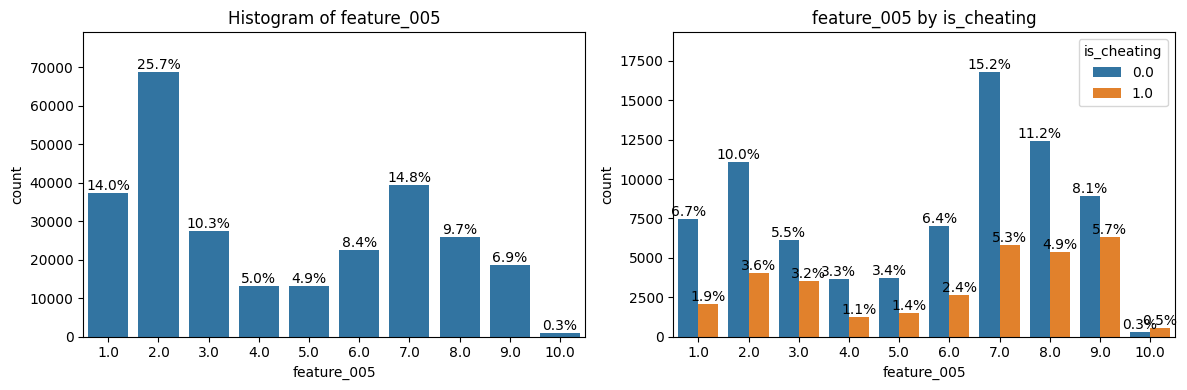

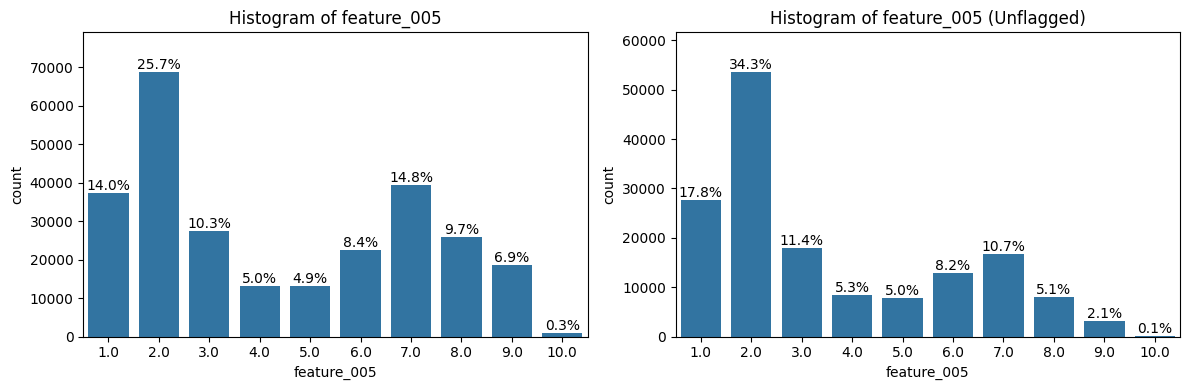

In [44]:
plot_categorical_labeled_view(data_train, "feature_005", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_005")

**Discussion.** No clear relationship with either the cheating status of reviewed candidates or the probability of being flagged is apparent for `feature_005`.

### `feature_006`

In [45]:
value_distribution(data_train, "feature_006")

feature_006
0.0         45859 (16.81%)
1.0         34076 (12.49%)
2.0         17290 ( 6.34%)
3.0          6607 ( 2.42%)
4.0          5058 ( 1.85%)
5.0         18636 ( 6.83%)
6.0         48191 (17.66%)
7.0         55476 (20.33%)
8.0         33202 (12.17%)
9.0          5791 ( 2.12%)
10.0          419 ( 0.15%)
Missing      2214 ( 0.81%)
Name: count, dtype: str

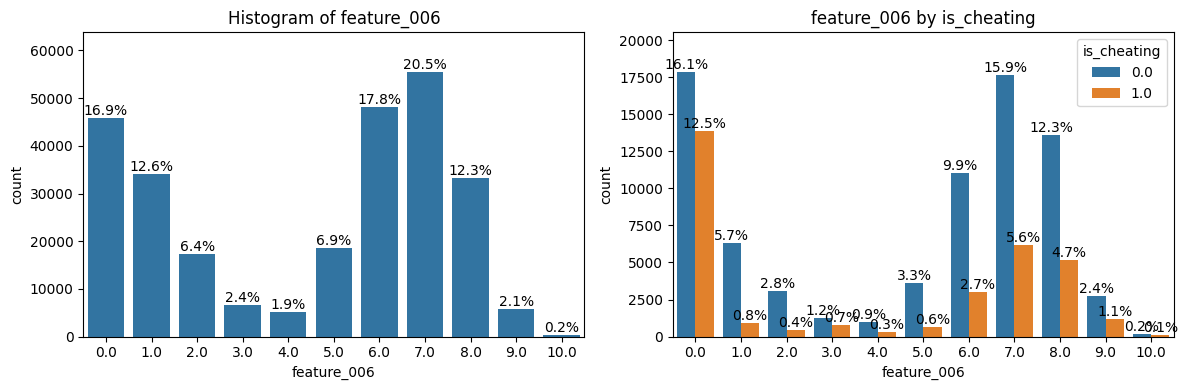

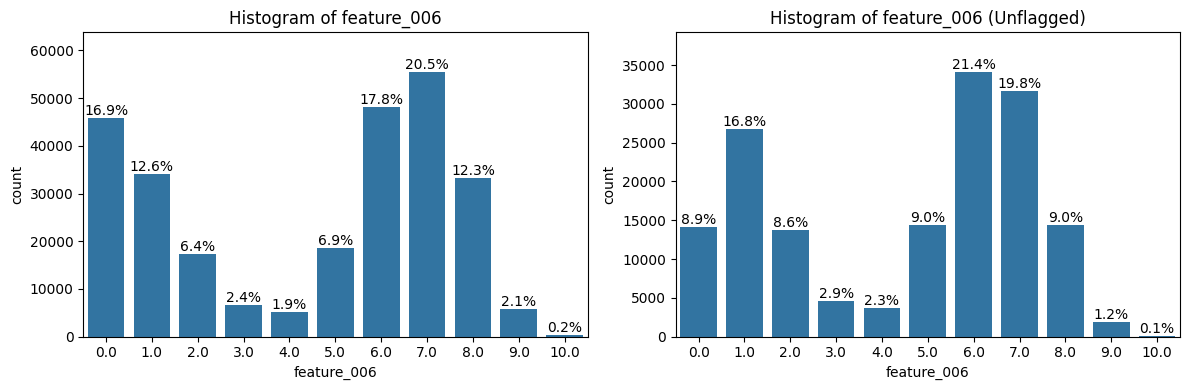

In [46]:
plot_categorical_labeled_view(data_train, "feature_006", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_006")

**Discussion.** No clear relationship with either the cheating status of reviewed candidates or the probability of being flagged is apparent for `feature_006`.

### `feature_007`

In [47]:
value_distribution(data_train, "feature_007")

feature_007
0.0         19875 ( 7.29%)
1.0        247109 (90.58%)
Missing      5835 ( 2.14%)
Name: count, dtype: str

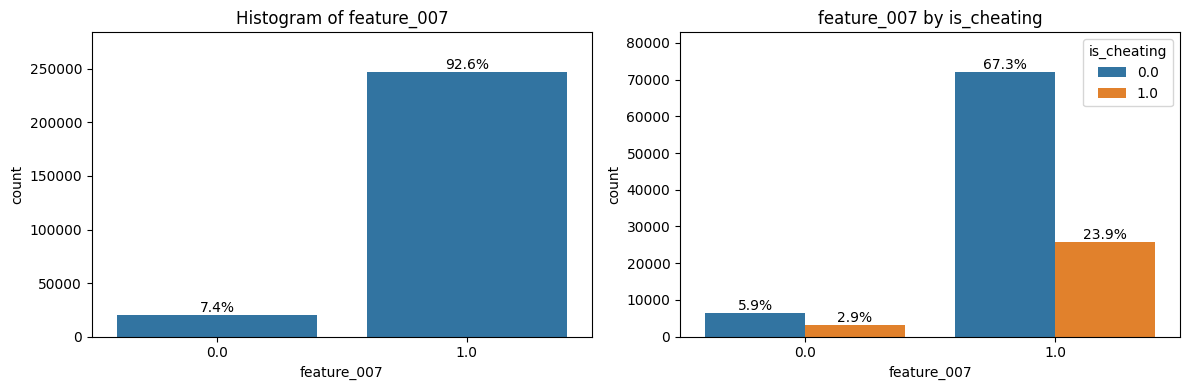

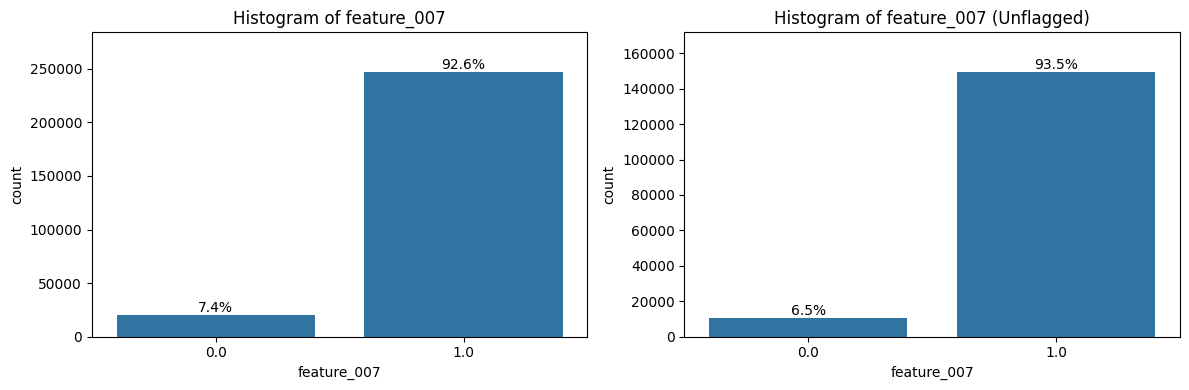

In [48]:
plot_categorical_labeled_view(data_train, "feature_007", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_007")

**Discussion.** No clear relationship with either the cheating status of reviewed candidates or the probability of being flagged is apparent for `feature_007`.

### `feature_008`

In [49]:
value_distribution(data_train, "feature_008")

feature_008
0.0         78004 (28.59%)
1.0         76705 (28.12%)
2.0          8933 ( 3.27%)
3.0          3910 ( 1.43%)
4.0          2646 ( 0.97%)
5.0           971 ( 0.36%)
6.0          3561 ( 1.31%)
7.0          5181 ( 1.90%)
8.0         16879 ( 6.19%)
9.0         45329 (16.62%)
10.0        24604 ( 9.02%)
Missing      6096 ( 2.23%)
Name: count, dtype: str

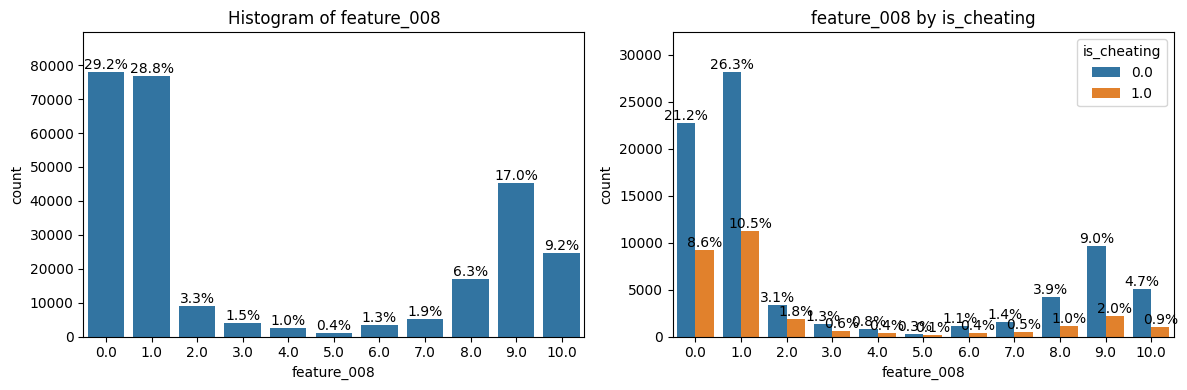

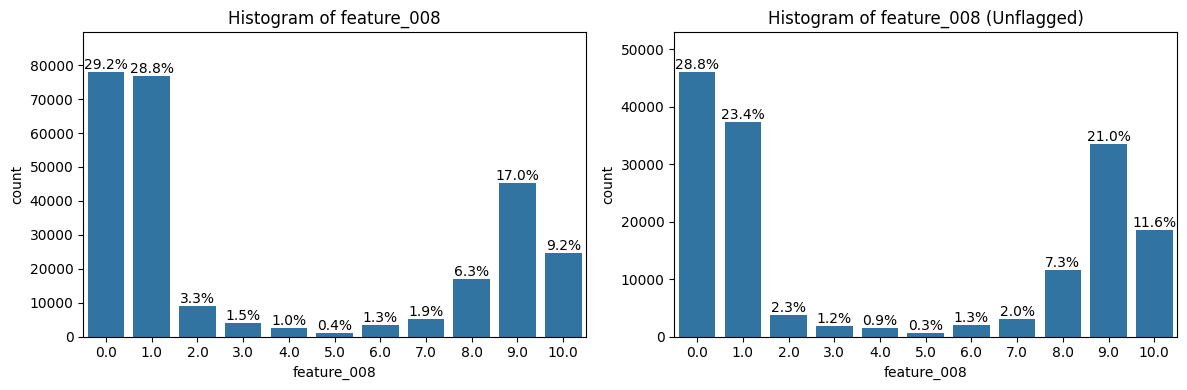

In [50]:
plot_categorical_labeled_view(data_train, "feature_008", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_008")

**Discussion.** No clear relationship with either the cheating status of reviewed candidates or the probability of being flagged is apparent for `feature_008`.

### `feature_009`

In [51]:
value_distribution(data_train, "feature_009")

feature_009
0.0        177847 (65.19%)
1.0         16425 ( 6.02%)
2.0          3613 ( 1.32%)
3.0           199 ( 0.07%)
4.0           161 ( 0.06%)
5.0            59 ( 0.02%)
6.0           159 ( 0.06%)
7.0           420 ( 0.15%)
8.0          2529 ( 0.93%)
9.0         51715 (18.96%)
10.0        13596 ( 4.98%)
Missing      6096 ( 2.23%)
Name: count, dtype: str

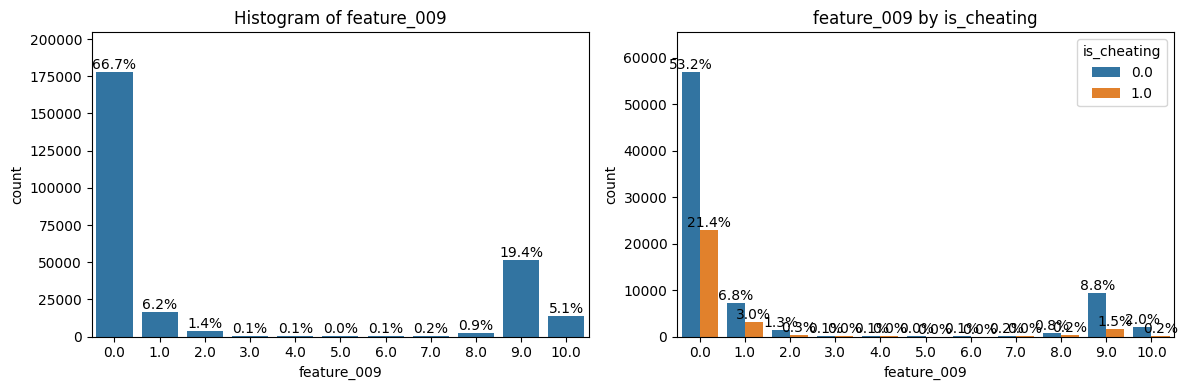

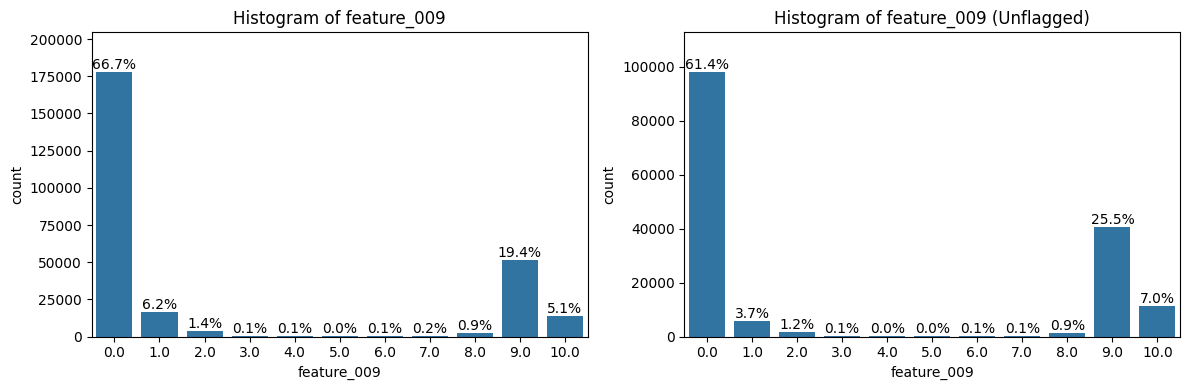

In [52]:
plot_categorical_labeled_view(data_train, "feature_009", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_009")

**Discussion.** No clear relationship with either the cheating status of reviewed candidates or the probability of being flagged is apparent for `feature_009`.

### `feature_010`

In [53]:
value_distribution(data_train, "feature_010")

feature_010
0.0           128728 (47.18%)
1.0             2549 ( 0.93%)
2.0             1519 ( 0.56%)
3.0             1114 ( 0.41%)
4.0              871 ( 0.32%)
                   ...       
2899149.0          1 ( 0.00%)
3673215.0          1 ( 0.00%)
4154567.0          1 ( 0.00%)
39128914.0         1 ( 0.00%)
Missing         6096 ( 2.23%)
Name: count, Length: 8155, dtype: str

In [54]:
data_train["feature_010"].describe()

count    2.667230e+05
mean     8.090543e+02
std      7.735875e+04
min      0.000000e+00
25%      0.000000e+00
50%      3.000000e+00
75%      5.050000e+02
max      3.912891e+07
Name: feature_010, dtype: float64

In [55]:
# Integer check,
data_train["feature_010"].dropna().mod(1).eq(0).all()

np.True_

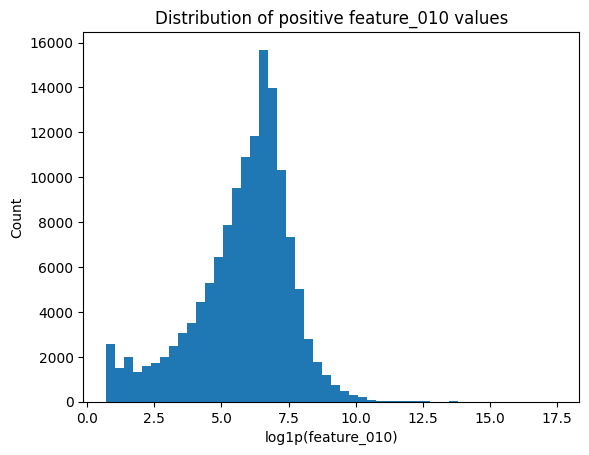

In [56]:
# Histogram (log scale, zeros omitted).
feature_name = "feature_010"
x = data_train[feature_name].dropna()
plt.hist(np.log1p(x[x > 0]), bins=50)
plt.xlabel(f"log1p({feature_name})")
plt.ylabel("Count")
plt.title(f"Distribution of positive {feature_name} values")
plt.show()

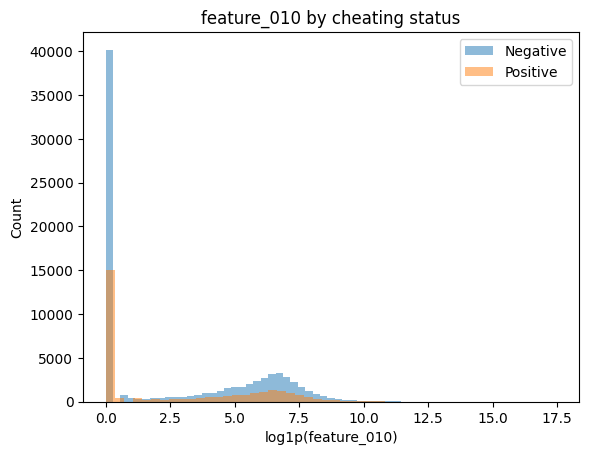

In [57]:
# Histogram overlap by class.
mask = target_train.notna()
x_negative = np.log1p(data_train.loc[mask & (target_train == 0), feature_name].dropna())
x_positive = np.log1p(data_train.loc[mask & (target_train == 1), feature_name].dropna())

plt.hist(x_negative, bins=50, alpha=0.5, label="Negative")
plt.hist(x_positive, bins=50, alpha=0.5, label="Positive")
plt.xlabel(f"log1p({feature_name})")
plt.ylabel("Count")
plt.title(f"{feature_name} by cheating status")
plt.legend()
plt.show()

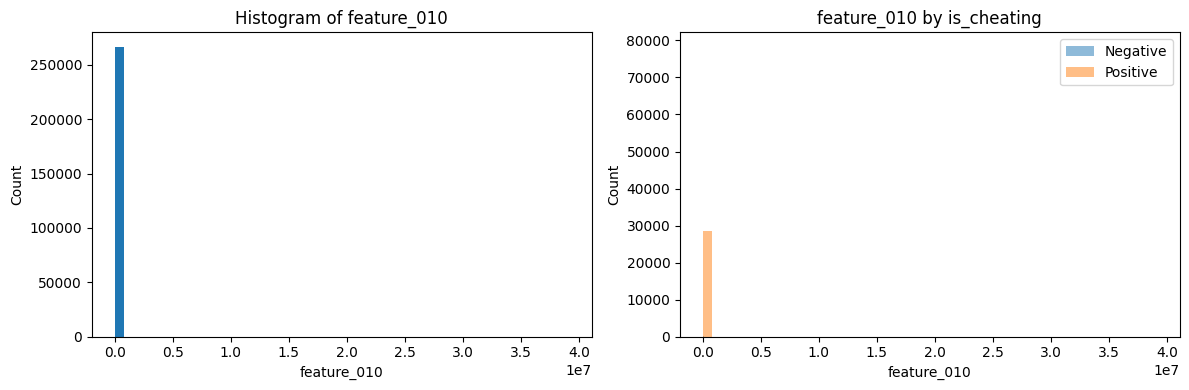

In [58]:
plot_numerical_labeled_view(data_train, "feature_010", target_train)

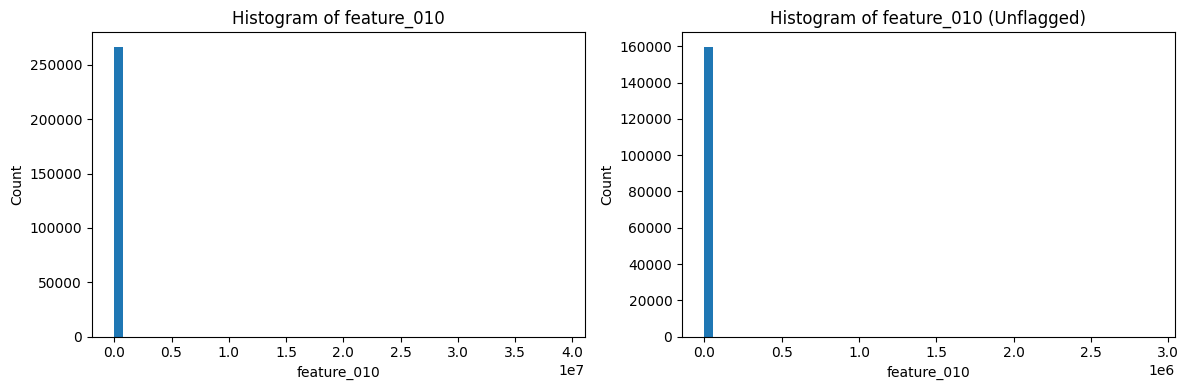

In [59]:
plot_numerical_unflagged_view(data_train, data_train_unflagged, "feature_010")

In [60]:
# Check skewness value.
data_train["feature_010"].dropna().skew()

np.float64(486.71861253653765)

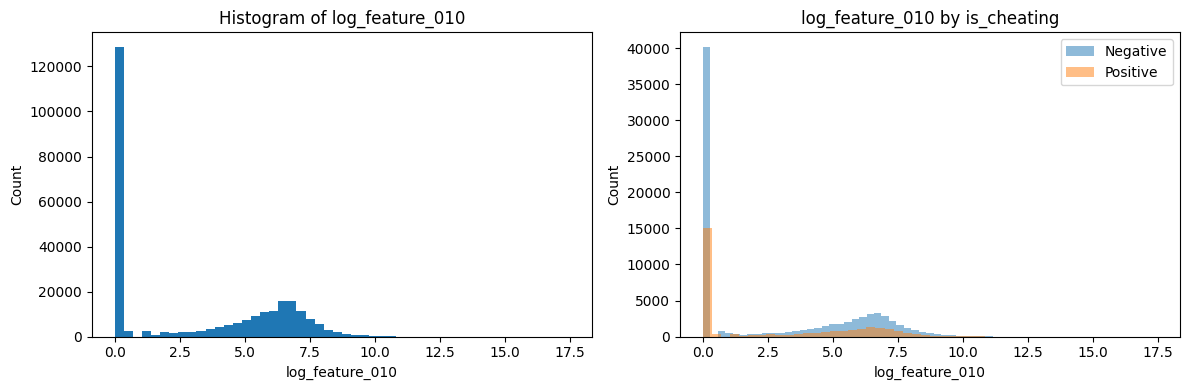

In [61]:
log_feature_010 = log_transform_and_plot(data_train, "feature_010", target_train)

In [62]:
binned_positive_rate(log_feature_010, target_train)

is_cheating,0.0,1.0,Positive Rate
feature_010,,,
"(-0.0175, 1.748]",42048,15920,27.5%
"(1.748, 3.496]",3115,1316,29.7%
"(3.496, 5.245]",7652,2769,26.6%
"(5.245, 6.993]",15863,5424,25.5%
"(6.993, 8.741]",8484,2810,24.9%
"(8.741, 10.489]",1129,361,24.2%
"(10.489, 12.238]",57,29,33.7%
"(12.238, 13.986]",6,4,40.0%
"(13.986, 15.734]",1,5,83.3%


**Discussion.** `feature_010` shows similar distributions for the Positive and Negative classes, with their relative proportions broadly matching the baseline Positive/Negative ratio. The feature does not appear to be informative of the target.

### `feature_011`

In [63]:
value_distribution(data_train, "feature_011")

feature_011
0.0        264251 (96.86%)
1.0          2752 ( 1.01%)
Missing      5816 ( 2.13%)
Name: count, dtype: str

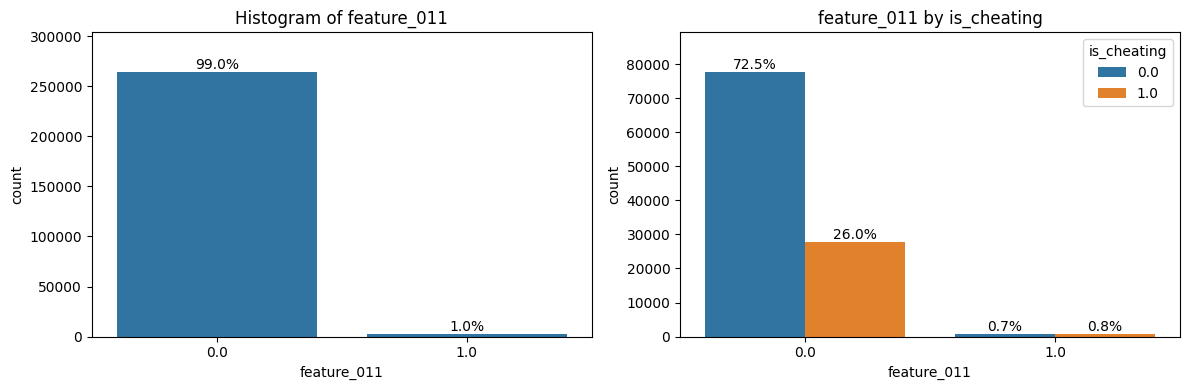

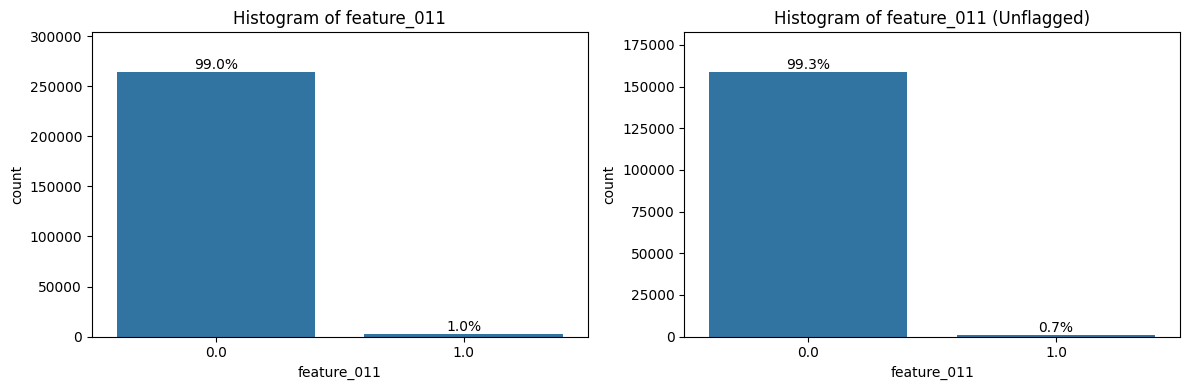

In [64]:
plot_categorical_labeled_view(data_train, "feature_011", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_011")

**Discussion.** No clear relationship with either the cheating status of reviewed candidates or the probability of being flagged is apparent for `feature_011`.

### `feature_012`

In [65]:
value_distribution(data_train, "feature_012")

feature_012
0.0        211651 (77.58%)
1.0         26497 ( 9.71%)
2.0         13618 ( 4.99%)
3.0          9761 ( 3.58%)
Missing     11292 ( 4.14%)
Name: count, dtype: str

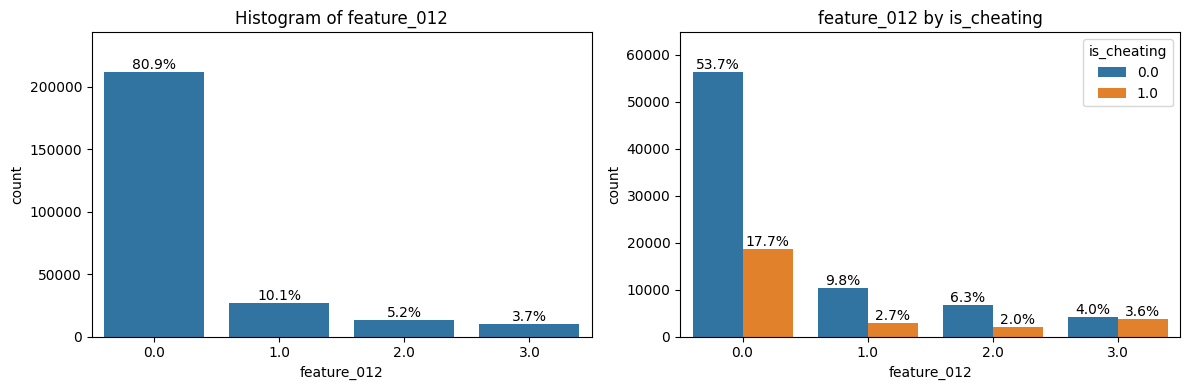

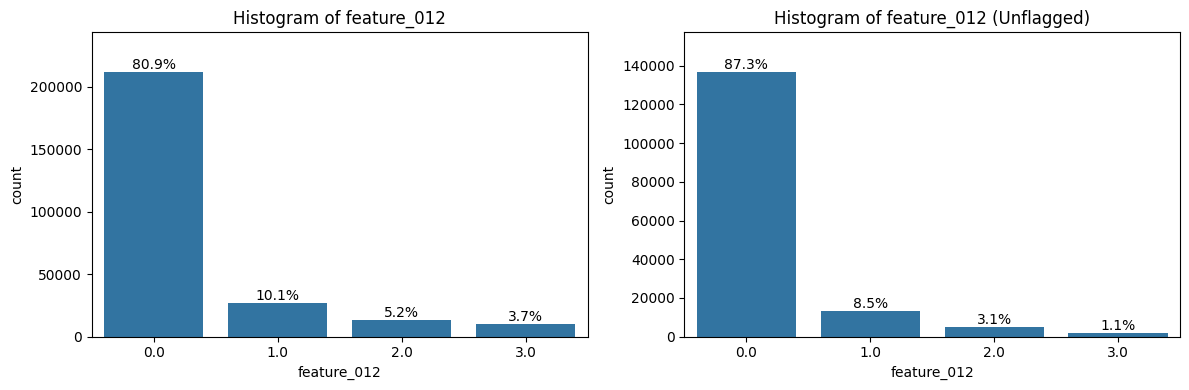

In [66]:
plot_categorical_labeled_view(data_train, "feature_012", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_012")

**Discussion.** `feature_012` is a categorical variable with four levels, with level 3 reported by only 3.7% of candidates. Level 3 is strongly overrepresented among reviewed candidates (7.6%) and underrepresented among unflagged candidates (1.1%). Among reviewed candidates, nearly half of those reporting level 3 are labeled as cheating (47%), compared with about 26% overall. This makes level 3 a particularly strong candidate for further investigation.

### `feature_013`

In [67]:
value_distribution(data_train, "feature_013")

feature_013
0.0        122732 (44.99%)
1.0        144271 (52.88%)
Missing      5816 ( 2.13%)
Name: count, dtype: str

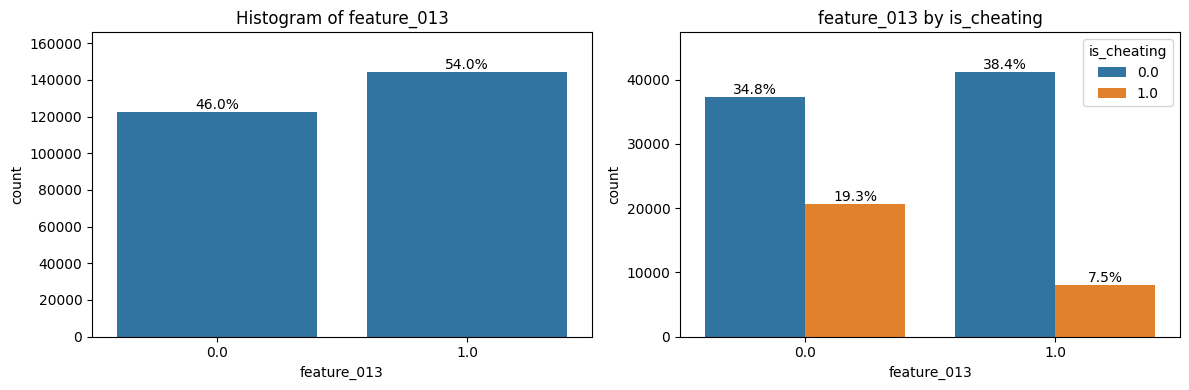

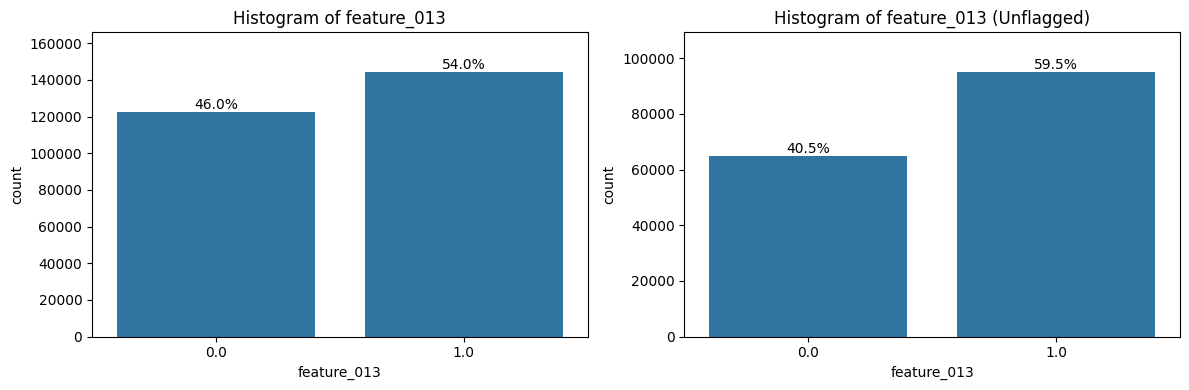

In [68]:
plot_categorical_labeled_view(data_train, "feature_013", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_013")

**Discussion.** `feature_013` is a binary variable with a relatively balanced distribution across the two levels. The two levels show substantially different distributions between reviewed and unflagged candidates, as well as markedly different Positive rates among reviewed candidates, indicating that `feature_013` carries useful information about cheating status.

### `feature_014`

In [69]:
value_distribution(data_train, "feature_014")

feature_014
0.0         44285 (16.23%)
1.0        222654 (81.61%)
Missing      5880 ( 2.16%)
Name: count, dtype: str

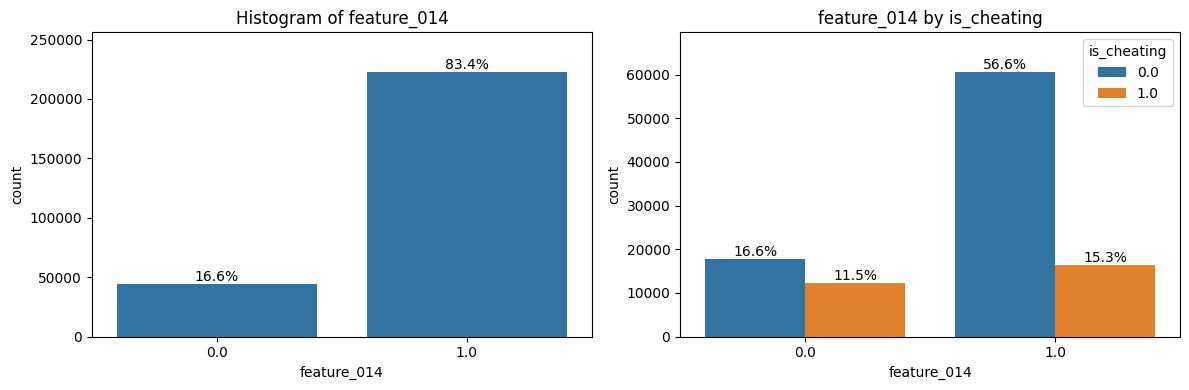

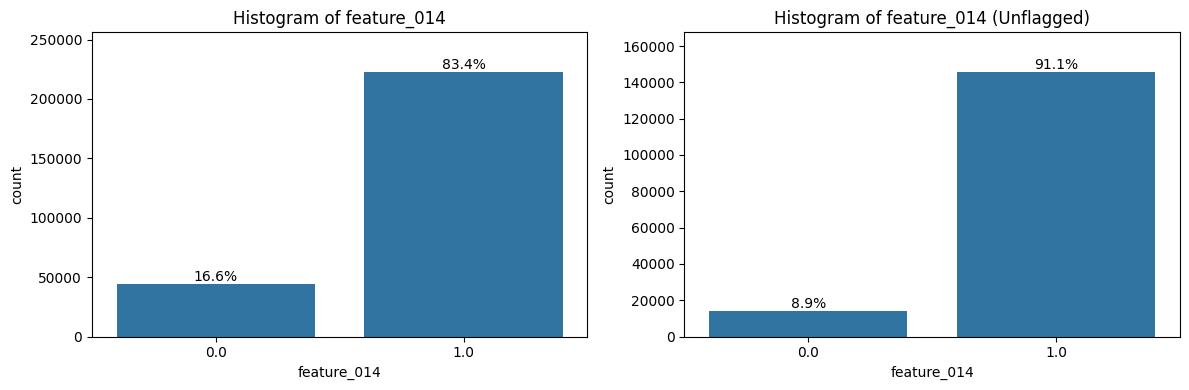

In [70]:
plot_categorical_labeled_view(data_train, "feature_014", target_train)
plot_categorical_unflagged_view(data_train, data_train_unflagged, "feature_014")

**Discussion.** `feature_014` is a highly imbalanced binary variable, with approximately 83% of observations taking value 1. Level 0 has a higher Positive rate than level 1 among reviewed candidates, and is also more common among reviewed candidates overall, while level 1 is more common among unflagged candidates.

### `feature_015`

In [71]:
data_train["feature_015"].describe()

count    272819.000000
mean         25.108919
std          72.878142
min          -7.008252
25%           0.039606
50%           0.705370
75%          13.845544
max         897.850613
Name: feature_015, dtype: float64

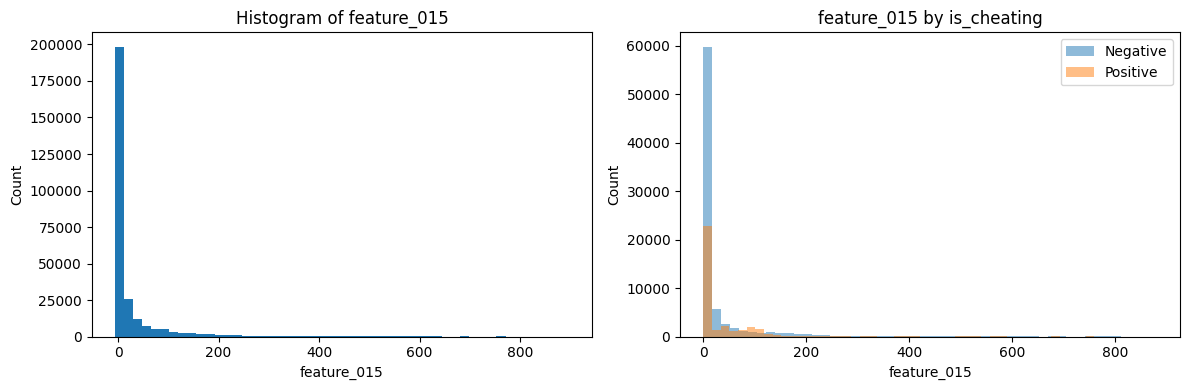

In [72]:
plot_numerical_labeled_view(data_train, "feature_015", target_train)

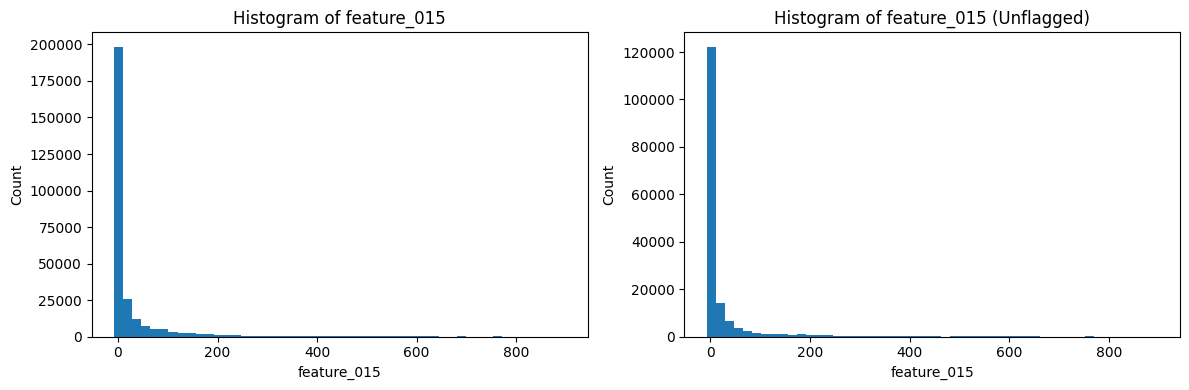

In [73]:
plot_numerical_unflagged_view(data_train, data_train_unflagged, "feature_015")

In [74]:
# Check skewness value.
data_train["feature_015"].dropna().skew()

np.float64(5.72699749970414)

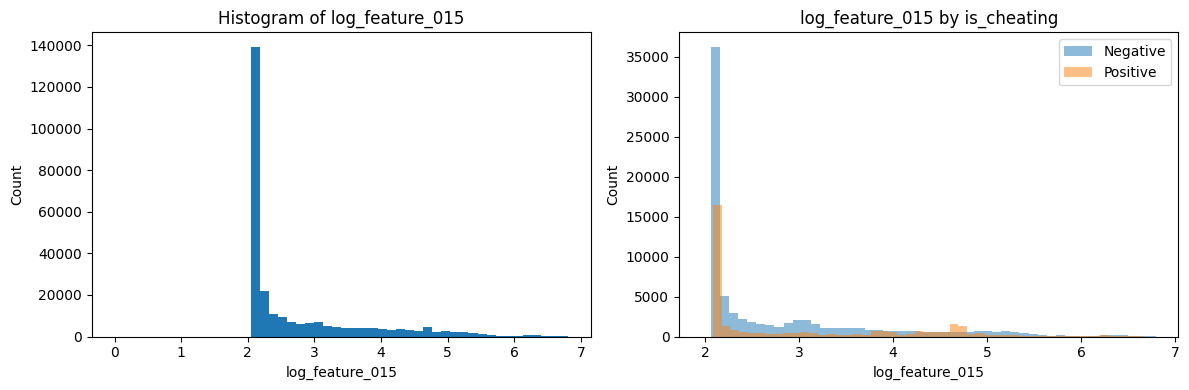

In [75]:
log_feature_015 = log_transform_and_plot(data_train, "feature_015", target_train)

In [76]:
log_feature_015.dropna().skew()

np.float64(1.651662812699155)

In [77]:
binned_positive_rate(log_feature_015, target_train)

is_cheating,0.0,1.0,Positive Rate
feature_015,,,
"(1.96, 2.448]",46580,19286,29.3%
"(2.448, 2.93]",7666,2118,21.6%
"(2.93, 3.413]",7800,1994,20.4%
"(3.413, 3.896]",4686,1843,28.2%
"(3.896, 4.378]",3411,2635,43.6%
"(4.378, 4.861]",2748,4532,62.3%
"(4.861, 5.344]",3164,1198,27.5%
"(5.344, 5.826]",1296,290,18.3%
"(5.826, 6.309]",647,385,37.3%


**Discussion.** `feature_015` is a highly right-skewed numerical variable (skewness ≈ 5.73), which a log transform (after shifting to account for negative values) reduces but does not eliminate (skewness ≈ 1.65). Binning the log-transformed values reveals a notable pattern: several bins show a Positive rate close to the baseline (\~20–30%), but two adjacent bins in the mid-to-upper range stand out with substantially higher Positive rates (43.6% and 62.3%, on 6,046 and 7,280 examples respectively). Overall, `feature_015` shows a clear relationship with the target.

### `feature_016`

In [78]:
value_distribution(data_train, "feature_016")

feature_016
0       28769 (10.55%)
1      138818 (50.88%)
2       40343 (14.79%)
3       18744 ( 6.87%)
4       10817 ( 3.96%)
            ...       
277         1 ( 0.00%)
326         1 ( 0.00%)
390         1 ( 0.00%)
555         1 ( 0.00%)
581         1 ( 0.00%)
Name: count, Length: 177, dtype: str

In [79]:
# Integer check,
data_train["feature_016"].dropna().mod(1).eq(0).all()

np.True_

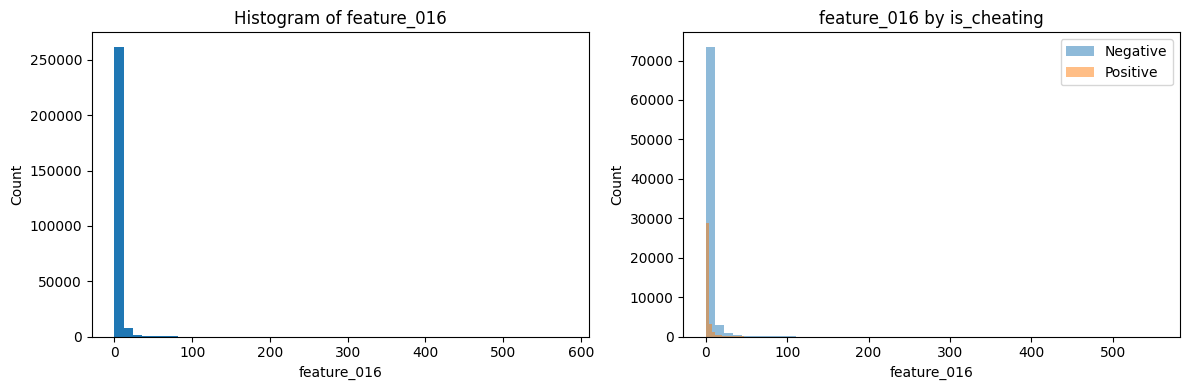

In [80]:
plot_numerical_labeled_view(data_train, "feature_016", target_train)

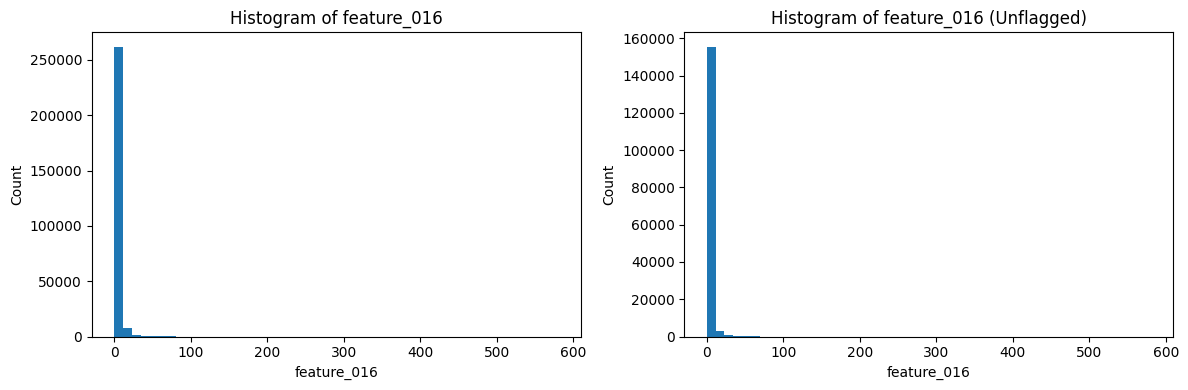

In [81]:
plot_numerical_unflagged_view(data_train, data_train_unflagged, "feature_016")

In [82]:
# Check skewness value.
data_train["feature_016"].dropna().skew()

np.float64(16.095504037721074)

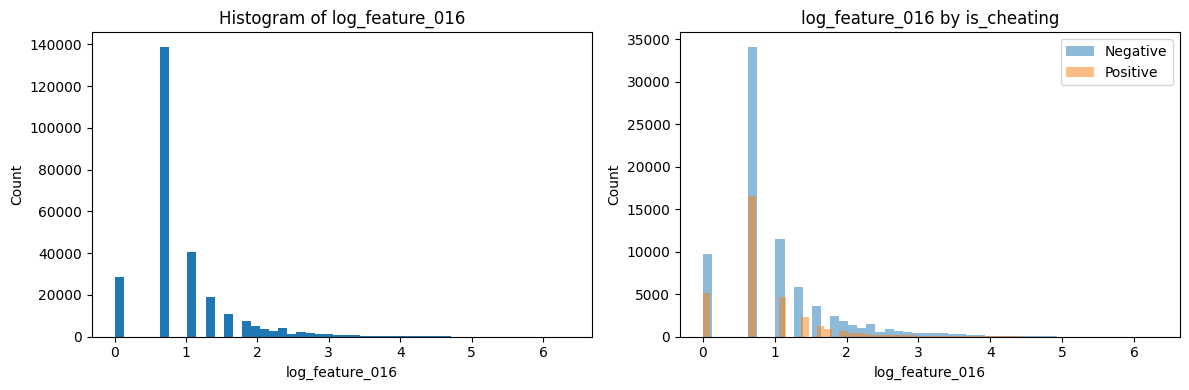

In [83]:
log_feature_016 = log_transform_and_plot(data_train, "feature_016", target_train)

In [84]:
binned_positive_rate(log_feature_016, target_train)

is_cheating,0.0,1.0,Positive Rate
feature_016,,,
"(-0.00632, 0.632]",9687,5094,34.5%
"(0.632, 1.264]",45619,21256,31.8%
"(1.264, 1.896]",11886,4485,27.4%
"(1.896, 2.528]",6292,2137,25.4%
"(2.528, 3.16]",3058,941,23.5%
"(3.16, 3.792]",1410,364,20.5%
"(3.792, 4.425]",447,123,21.6%
"(4.425, 5.057]",110,28,20.3%
"(5.057, 5.689]",25,3,10.7%


**Discussion.** `feature_016` is a heavily right-skewed integer variable (skewness ≈ 16), even more skewed than `feature_015`. A log transform reduces the skew, but the resulting Positive rate across bins shows no distinct region standing out. `feature_016` does not appear to be informative of the target.

### `feature_017`

In [85]:
data_train["feature_017"].describe()

count    244050.000000
mean         13.805947
std           6.145651
min           0.000000
25%           9.616667
50%          14.650000
75%          18.695121
max          24.000000
Name: feature_017, dtype: float64

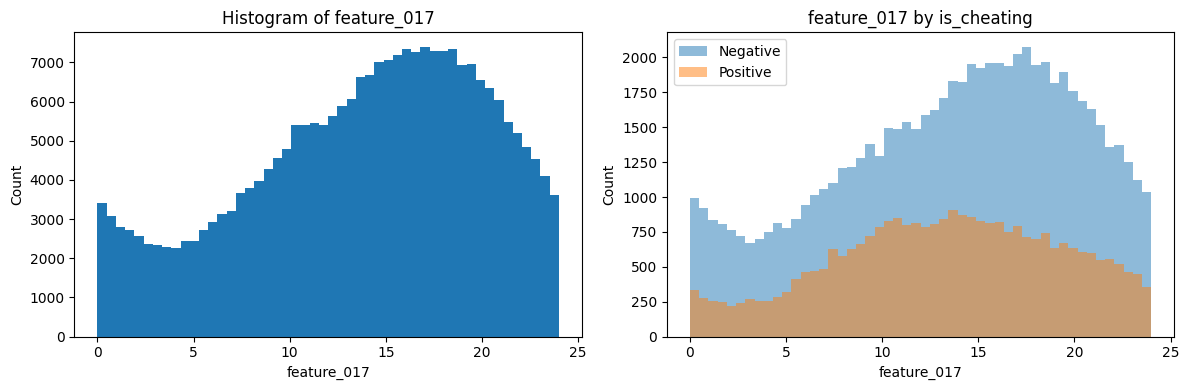

In [86]:
plot_numerical_labeled_view(data_train, "feature_017", target_train)

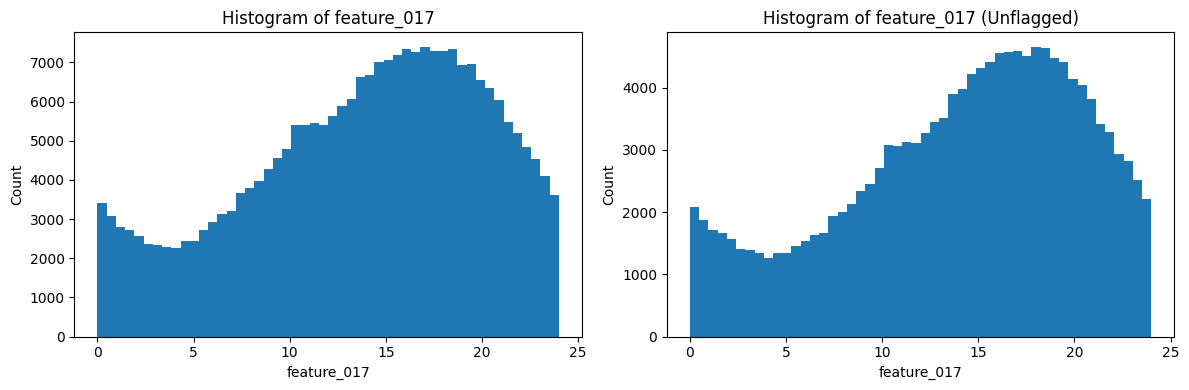

In [87]:
plot_numerical_unflagged_view(data_train, data_train_unflagged, "feature_017")

In [88]:
binned_positive_rate(data_train["feature_017"], target_train)

is_cheating,0.0,1.0,Positive Rate
feature_017,,,
"(-0.024, 2.4]",4315,1334,23.6%
"(2.4, 4.8]",3650,1301,26.3%
"(4.8, 7.2]",4636,2143,31.6%
"(7.2, 9.6]",6179,3212,34.2%
"(9.6, 12.0]",7325,4099,35.9%
"(12.0, 14.4]",8543,4197,32.9%
"(14.4, 16.8]",9773,4087,29.5%
"(16.8, 19.2]",9837,3579,26.7%
"(19.2, 21.6]",8443,3039,26.5%


**Discussion.** `feature_017`'s distribution has a main peak around 16-18 and a smaller uptick near 0, with a minimum around 4-5 separating them. More notably, the Positive and Negative distributions are shifted relative to each other: Positive examples peak earlier (\~10-14), while Negative examples peak later (\~15-20), suggesting `feature_017` carries some signal for the target.

### `feature_018`

In [89]:
data_train["feature_018"].describe()

count    245184.000000
mean          0.574001
std           0.226960
min           0.000000
25%           0.425000
50%           0.600000
75%           0.750000
max           1.000000
Name: feature_018, dtype: float64

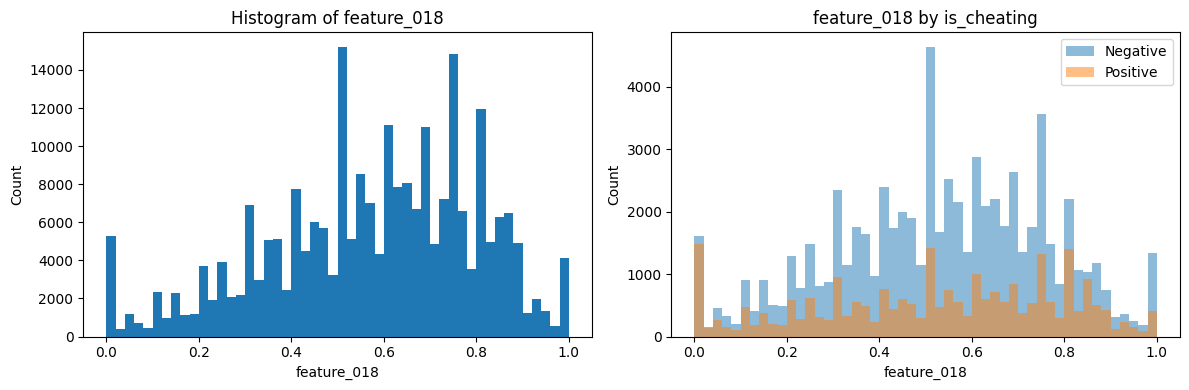

In [90]:
plot_numerical_labeled_view(data_train, "feature_018", target_train)

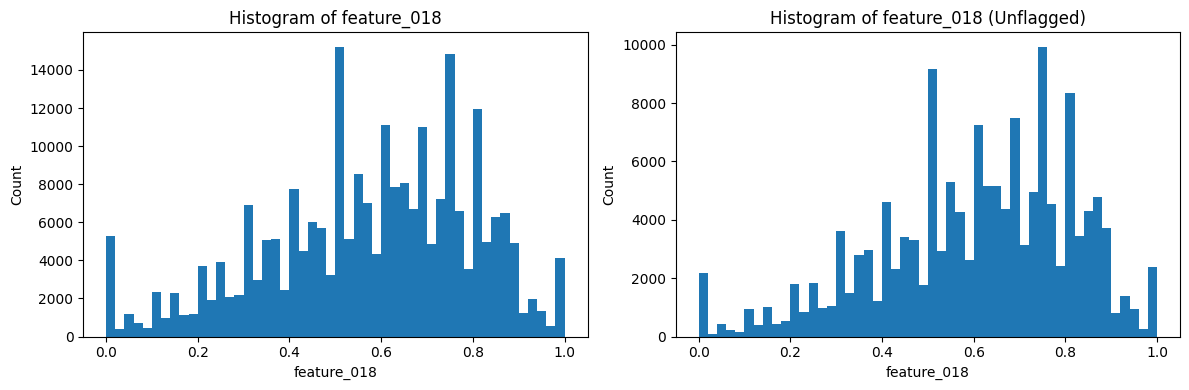

In [91]:
plot_numerical_unflagged_view(data_train, data_train_unflagged, "feature_018")

In [92]:
binned_positive_rate(data_train["feature_018"], target_train)

is_cheating,0.0,1.0,Positive Rate
feature_018,,,
"(-0.001, 0.1]",2780,2138,43.5%
"(0.1, 0.2]",3219,1425,30.7%
"(0.2, 0.3]",5237,2053,28.2%
"(0.3, 0.4]",7869,2563,24.6%
"(0.4, 0.5]",12336,3597,22.6%
"(0.5, 0.6]",9205,2529,21.6%
"(0.6, 0.7]",11558,3712,24.3%
"(0.7, 0.8]",8997,3084,25.5%
"(0.8, 0.9]",6230,3676,37.1%


**Discussion.** `feature_018` has a roughly unimodal distribution centered around 0.5–0.6, with pronounced spikes at several specific values whose cause is unclear. It also shows elevated Positive rates at both ends of its range: the lowest bin (0–0.1, 43.5% Positive) and a bin near the high end (0.8–0.9, 37.1% Positive) stand out, while the middle bins remain closer to the baseline (\~22–28%). This suggests that feature_018 carries useful information about the target.

### Conclusion

Most features show little evidence of a meaningful relationship with cheating status or flagging probability. A smaller group stands out: `feature_004`, `feature_012`, and `feature_013` show particularly notable associations, while `feature_001` and `feature_002` appear more closely related to the flagging process. Among the numerical features, `feature_015`, `feature_017`, and `feature_018` show the clearest evidence of target-related patterns.

## Duplicates

In [93]:
combined_user_hashes = pd.concat([data_train["user_hash"], data_test["user_hash"]])
combined_user_hashes.nunique() == len(combined_user_hashes)

True

**Findings.**
- No duplicate user_hash values exist across the combined train-test data.
- Duplicate edges were already identified in the social graph during the earlier directionality investigation; they are discussed in the Social Graph Analysis section below.

## Missing Values

In [94]:
print(f"Train samples: {len(data_train)}")

Train samples: 272819


In [95]:
missing_counts = data_train.isna().sum()
missing_rates = (missing_counts / len(data_train) * 100).round(2)
missing_rates_str = missing_rates.astype(str) + "%"

pd.DataFrame({"Missing Count": missing_counts, "Missing Rate (%)": missing_rates_str})

,Missing Count,Missing Rate (%)
user_hash,0,0.0%
feature_001,32115,11.77%
feature_002,31705,11.62%
feature_003,31705,11.62%
feature_004,2399,0.88%
feature_005,5799,2.13%
feature_006,2214,0.81%
feature_007,5835,2.14%
feature_008,6096,2.23%
feature_009,6096,2.23%


In [96]:
from itertools import combinations


def same_missing_rows(df, feature_a, feature_b):
    return df[feature_a].isna().equals(df[feature_b].isna())


groups = [
    ["feature_002", "feature_003"],
    ["feature_005", "feature_011", "feature_013"],
    ["feature_008", "feature_009", "feature_010"],
]

for group in groups:
    for feature_a, feature_b in combinations(group, 2):
        print(feature_a, feature_b, same_missing_rows(data_train, feature_a, feature_b))

feature_002 feature_003 True
feature_005 feature_011 False
feature_005 feature_013 False
feature_011 feature_013 True
feature_008 feature_009 True
feature_008 feature_010 True
feature_009 feature_010 True


**Co-Missingness.** Some features are always missing together: `feature_002`/`feature_003`, `feature_011`/`feature_013`, and `feature_008`/`feature_009`/`feature_010`. In contrast, `feature_005` does not share missing rows with either `feature_011` or `feature_013`.

**Data Leakage Warning.** We deliberately avoid inspecting test data beyond basic structural checks (e.g. shape, column presence) that do not inform modeling decisions. We therefore do not analyze test data for missing values. Instead, we assume that unseen data may contain missing values and will build imputation into the pipeline accordingly, rather than using test-data inspection to determine this choice.

### Imputation considerations

In [97]:
features = categorical_features + numerical_features
any_missing = data_train[features].isna().any(axis=1)
print(
    f"Fraction of rows with at least one missing value: "
    f"{any_missing.mean():.2%}"
)

Fraction of rows with at least one missing value: 28.47%


Missing values in the training data range up to \~12% per feature. Several features share exact missing-row patterns: `feature_002`/`feature_003`, `feature_011`/`feature_013`, and `feature_008`/`feature_009`/`feature_010` are always missing together, suggesting that they may be computed or sourced as a single unit. `feature_005` has the same missing rate as `feature_011`/`feature_013`, but is missing on different rows.

The competition description explicitly states that missing values are informative. This argues against simply deleting incomplete rows or imputing all missing values with a mean, median, or mode, since these approaches can discard information carried by missingness itself. Even without this consideration, 28.47% of training rows contain at least one missing value, making row-wise deletion unnecessarily costly in terms of available training data.

For categorical and binary features, treating missing as an explicit category is a natural candidate. These features may represent questionnaire responses, in which case leaving a question unanswered could itself carry information. We therefore consider missing-as-category as an all-or-nothing strategy for categorical and binary features.

For numerical features, candidate approaches include a simple baseline imputer, linear MICE, and tree-based MICE. These represent different modeling assumptions and provide a useful range of increasingly flexible approaches. Explicit missingness indicators may also be considered to preserve information carried by the missingness pattern itself.

The co-missing feature groups suggest a possible future enhancement: imputing features jointly within these groups rather than independently. We leave this as a potential extension rather than a committed approach, since it would require custom implementation.

We currently do not plan to use the social graph for feature imputation. The referral relationship does not necessarily imply feature similarity, and using the same graph for both feature imputation and label propagation could introduce an artificial relationship between imputed features and labels. We therefore favor reserving the graph for label propagation and handling missing features separately.

Whatever imputation strategy is ultimately selected, it will be implemented within the modeling pipeline, fitted on training data and applied to unseen data without inspecting test missingness.


## Outliers

**Findings.** Outlier inspection does not reveal obvious anomalous observations. The categorical features have sufficiently populated levels overall, with the exception of the single 0 value in `feature_004`, which is flagged for consideration during preprocessing. `feature_017` shows no isolated extreme values, while `feature_018` is naturally bounded between 0 and 1. `feature_010`, `feature_015`, and `feature_016` are strongly right-skewed, but their extreme values appear to be part of their underlying distributions rather than isolated data errors.

## Relationships

We examine pairwise relationships using measures appropriate to the variable types: Pearson and Spearman correlation for numerical variables, Cramér's V for categorical variables, and the correlation ratio for categorical–numerical pairs.

### Numerical-numerical relationships

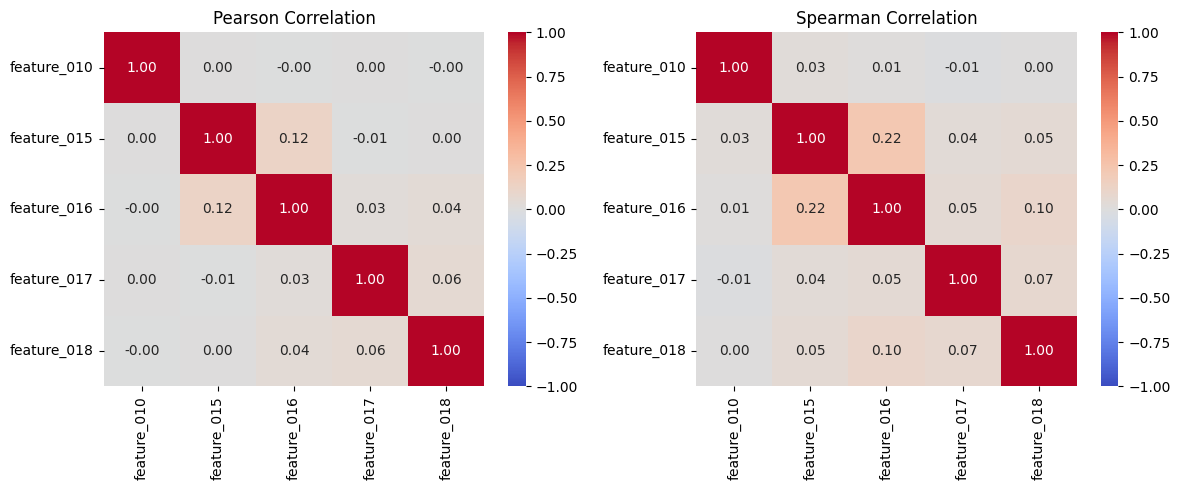

In [98]:
pearson_corr = data_train[numerical_features].corr(method="pearson")
spearman_corr = data_train[numerical_features].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson Correlation")
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman Correlation")
plt.tight_layout()
plt.show()

**Findings.** Pearson and Spearman correlations reveal no strong relationships among the numerical features. The largest association is between `feature_015` and `feature_016` (Pearson = 0.121, Spearman = 0.224), which remains weak and does not indicate substantial feature redundancy. Overall, the numerical features appear to provide largely independent information.

### Categorical-categorical relationships

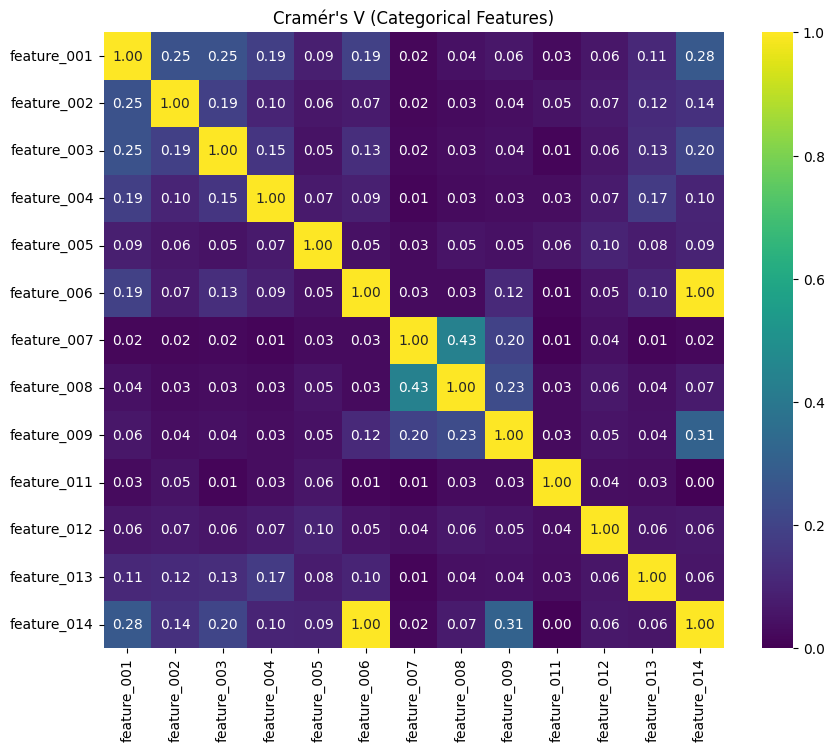

In [99]:
from scipy.stats import chi2_contingency


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cramers_matrix = pd.DataFrame(
    index=categorical_features, columns=categorical_features, dtype=float
)

for f1 in categorical_features:
    for f2 in categorical_features:
        mask = data_train[f1].notna() & data_train[f2].notna()
        cramers_matrix.loc[f1, f2] = cramers_v(
            data_train.loc[mask, f1], data_train.loc[mask, f2]
        )

plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Cramér's V (Categorical Features)")
plt.show()

In [100]:
pd.crosstab(
    data_train["feature_006"],
    data_train["feature_014"],
    margins=True,
)

feature_014,0.0,1.0,All
feature_006,,,
0.0,44272,0,44272
1.0,2,33822,33824
2.0,0,17156,17156
3.0,0,5987,5987
4.0,0,4865,4865
5.0,0,18609,18609
6.0,2,47850,47852
7.0,3,54836,54839
8.0,4,32857,32861


**Findings.** Most categorical features show weak associations with one another. The notable exception is `feature_006` and `feature_014` (Cramér's V ≈ 0.9998): `feature_014` is almost entirely determined by whether `feature_006` is zero, with only 15 exceptions. Both features have low missingness (`feature_006`: 0.81%; `feature_014`: 2.14%). `feature_007` and `feature_008` show a weaker association (V ≈ 0.434), while the remaining feature pairs show relatively low associations.

### Mixed-variable relationships

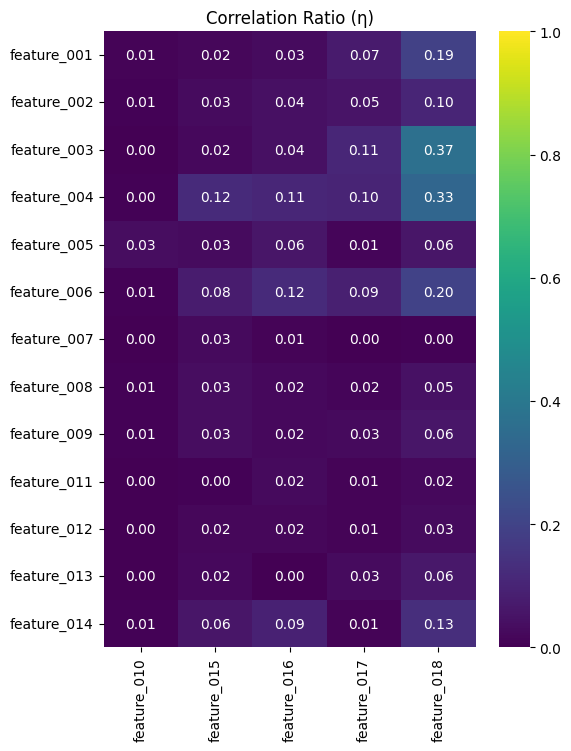

In [101]:
def correlation_ratio(categorical, numerical):
    mask = categorical.notna() & numerical.notna()
    categorical = categorical[mask]
    numerical = numerical[mask]

    overall_mean = numerical.mean()
    group_means = numerical.groupby(categorical).mean()
    group_sizes = numerical.groupby(categorical).size()

    ss_between = (group_sizes * (group_means - overall_mean) ** 2).sum()
    ss_total = ((numerical - overall_mean) ** 2).sum()

    return np.sqrt(ss_between / ss_total)


eta_matrix = pd.DataFrame(
    index=categorical_features, columns=numerical_features, dtype=float
)

for cat in categorical_features:
    for num in numerical_features:
        eta_matrix.loc[cat, num] = correlation_ratio(
            data_train[cat], data_train[num]
        )

plt.figure(figsize=(6, 8))
sns.heatmap(eta_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Correlation Ratio (η)")
plt.show()

**Findings.** The mixed-variable relationships are mostly weak. The largest η values are observed between `feature_018` and `feature_003` (η ≈ 0.366) and `feature_004` (η ≈ 0.325), followed by `feature_006` (η ≈ 0.199) and `feature_001` (η ≈ 0.194). The remaining pairs have η values of 0.13 or lower.

### Feature-target and feature-flagging relationships

In [102]:
flagged_status = target_train.notna()

results = []

for feature in categorical_features:
    mask_target = target_train.notna()
    assoc_target = cramers_v(data_train.loc[mask_target, feature], target_train[mask_target])
    assoc_flag = cramers_v(data_train[feature], flagged_status)
    results.append((feature, "Cramér's V", assoc_target, assoc_flag))

for feature in numerical_features:
    mask_target = target_train.notna()
    assoc_target = correlation_ratio(target_train[mask_target], data_train.loc[mask_target, feature])
    assoc_flag = correlation_ratio(flagged_status, data_train[feature])
    results.append((feature, "η", assoc_target, assoc_flag))

relevance_table = pd.DataFrame(
    results, columns=["Feature", "Measure", "Association with is_cheating", "Association with high_conf_clean"]
)
relevance_table = relevance_table.sort_values("Feature")
relevance_table = relevance_table.set_index("Feature")
relevance_table

,Measure,Association with is_cheating,Association with high_conf_clean
Feature,,,
feature_001,Cramér's V,0.147322,0.661837
feature_002,Cramér's V,0.179759,0.500245
feature_003,Cramér's V,0.103932,0.453698
feature_004,Cramér's V,0.255554,0.420291
feature_005,Cramér's V,0.142767,0.391835
feature_006,Cramér's V,0.225826,0.358860
feature_007,Cramér's V,0.039459,0.042340
feature_008,Cramér's V,0.110815,0.215177
feature_009,Cramér's V,0.118826,0.248335


**Findings.** Several features are substantially more strongly associated with `high_conf_clean` than with `is_cheating`, particularly `feature_001`, `feature_002`, `feature_003`, and `feature_005`. This is consistent with the Variable Inspection findings, where these features showed pronounced differences between flagged and unflagged candidates. For example, `feature_001` has Cramér's V of 0.662 with flagging versus 0.147 with cheating, consistent with the strong effect previously observed for level 1. `feature_013` is a notable exception, showing a stronger association with cheating (0.217) than with flagging (0.133), consistent with its observed Positive-rate differences. Two results merit a caveat: `feature_012` and `feature_015` show weaker aggregate associations here than their Variable Inspection findings might suggest, since their strongest patterns were concentrated in a single rare level or narrow range that an aggregate measure can understate. Overall, the aggregate measures reinforce the feature-level findings and provide quantitative support for the sampling-bias hypothesis.

**Potential feature interactions.** Relationships between combinations of features may contain additional predictive information, but systematic interaction discovery is better addressed during modeling than through exhaustive exploratory analysis.

## Sampling Bias

### Evidence for sampling bias

**Evidence from Variable Inspection.** Several features show systematic differences between reviewed and unflagged candidates, providing evidence that the reviewed population is not a random sample of all candidates. In particular, `feature_001`, `feature_002`, `feature_004`, `feature_012`, `feature_013`, and `feature_014` show notable differences in the distribution of feature levels between the two populations. For some of these features, the levels that differ between reviewed and unflagged candidates also show different Positive rates among reviewed candidates, as seen particularly for `feature_001`, `feature_004`, `feature_012`, and `feature_013`. These differences are consistent with the competition's warning that sampling bias is an important aspect of the problem.

**Evidence from Relationships.** The quantitative associations reinforce these observations. Several features are substantially more strongly associated with high_conf_clean than with is_cheating, indicating that the flagging mechanism is related to candidate features independently of their observed cheating status. This provides further evidence that the reviewed candidates were selectively sampled rather than drawn randomly from the candidate population.

**Interpretation.**

The competition explicitly identifies sampling bias as one of the intended challenges. This is consistent with a structural fact already established: `is_cheating` and `high_conf_clean` are mutually exclusive, indicating that labeled examples come specifically from candidates sent for manual review rather than from a random sample of all candidates.

We hypothesize, as a working explanation rather than a certainty, that an automated mechanism selects candidates for review based on their features, while unflagged candidates are assumed clean (`high_conf_clean = 1`). Under this hypothesis, the labeled data is biased toward candidates considered suspicious by the flagging mechanism, which may not coincide with candidates who are actually cheating.

Several features in the Variable Inspection section show evidence consistent with this hypothesis. For example, level 1 of `feature_001` is strongly
overrepresented among unflagged candidates and, when reviewed, is overwhelmingly Negative, while level 5 shows the opposite pattern. If some level-1 candidates are actually cheating, the flagging mechanism would rarely identify them for review, leaving few labeled examples from which a model could learn this pattern. A model trained only on labeled data could therefore inherit the flagging mechanism's blind spots rather than overcome them.

The observed class distribution among reviewed candidates should also be interpreted in this context; its implications are discussed separately in the Class Imbalance section.

**Implication for class imbalance.** The sampling bias provides important context for interpreting class imbalance: the observed Positive/Negative ratio applies only to the reviewed candidates and may not reflect the prevalence of cheating in the full candidate population. Class imbalance should therefore be assessed separately from the potential sampling bias affecting which candidates are reviewed.

### Addressing sampling bias

**Possible Approaches.**
- **Propensity-based weighting:** Correct the selection bias in the labeled sample by estimating the probability of being flagged and using it to reweight the reviewed candidates during training. This approach addresses the sampling bias but relies exclusively on the observed labels.
- **Label imputation:** Mitigate the effects of selective labeling by imputing labels for the unreviewed population. This can make use of information beyond the reviewed subset, such as the social graph, through graph-based label propagation (PA), or more generally through a Positive-Unlabeled (PU) learning framework designed for settings with labeled and unlabeled examples. This approach is particularly attractive here because about 59% of the training candidates are unlabeled, so an approach that relies exclusively on the reviewed subset would leave a large portion of the available data unused.

**Limitations.** Neither approach can eliminate the underlying bias completely, since the true selection mechanism and the labels of the unreviewed candidates remain unknown.

## Class Imbalance

### Evidence for class imbalance

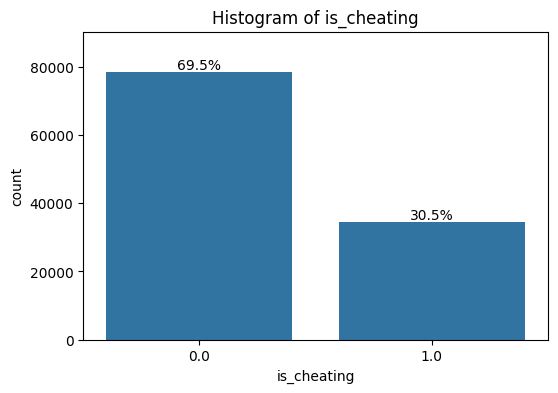

In [103]:
_ = plot_categorical_histogram(data_train, target_name)

**Observed class imbalance.** The labeled candidates are imbalanced, with Negative examples substantially outnumbering Positive examples. The observed ratio is approximately 2.3:1 in favor of Negative examples.

**Implication of sampling bias.** This class distribution applies only to the reviewed candidates and may not reflect the true class distribution of the full candidate population because the reviewed candidates were not selected randomly.

**Estimating population imbalance.** The class distribution of the full candidate population can be estimated after addressing the sampling bias. With propensity weighting, the estimate is obtained from the weighted labeled sample; with label imputation, such as graph-based label propagation, it is obtained from the inferred labels for the unreviewed candidates.

### Addressing class imbalance

**Possible Approaches.**

- **Class weighting.** Keep the original training data and its observed class distribution, but assign greater weight to the minority class during training. This preserves the data distribution while preventing the majority class from dominating the learning objective.
- **Minority oversampling.** Keep all original examples but add sampled copies of minority-class examples, typically with replacement, to make the training classes more balanced. This gives the learner more minority examples but changes the class distribution it sees during training.

**Limitations.** Both approaches address the observed class imbalance, but their effectiveness depends on how well the observed class distribution represents the relevant candidate population. Because of the sampling bias discussed above, the true population imbalance must first be estimated or approximated.

## Social Graph Analysis

### Initial observations

Based on our [initial exploration of the social graph](#Social-graph), the social graph contains approximately 1.71 million edge records and covers roughly 73% of candidates in the training set. The graph contains a small number of exact duplicate edge records (4,313) and reverse-pair overlaps (1,312). These observations alone do not establish whether the graph should be treated as directed or undirected, although Mercor's external contest listing identifies it as a referral graph, suggesting a directed relationship. The graph therefore appears to provide substantial coverage across the candidate population and may contain useful information for label propagation.

For reference, the label-by-graph coverage table from [Dataset statistics](#Dataset-statistics) is repeated below.

In [104]:
print("Train:\n" + "-" * 50)
label_graph_summary_table(data_train, graph_users)

Train:
--------------------------------------------------


,In graph,Outside graph,Total
Positive,22049 (8.08%),12382 (4.54%),34431 (12.62%)
Negative,60104 (22.03%),18431 (6.76%),78535 (28.79%)
Labeled,82153 (30.11%),30813 (11.29%),112966 (41.41%)
Unlabeled,115767 (42.43%),44086 (16.16%),159853 (58.59%)
Total,197920 (72.55%),74899 (27.45%),272819 (100.0%)


**Findings.** Graph coverage differs across label groups: approximately 64.0% of Positive candidates, 76.5% of Negative candidates, and 72.4% of Unlabeled candidates occur in the graph. Thus, Positive candidates have lower graph coverage than Negative candidates. At the same time, most graph-connected candidates are Unlabeled (58.5%), indicating that the graph contains a substantial unlabeled population that could potentially benefit from label propagation.

### Repeated edges

In [105]:
edge_counts = social_graph.groupby(["user_a", "user_b"]).size()
edge_counts.value_counts().sort_index()

1    1706156
2       4276
3         17
4          1
Name: count, dtype: int64

In [106]:
repeated_edges = edge_counts[edge_counts > 1]

repeat_referrers = repeated_edges.index.get_level_values("user_a").unique()
train_repeat_referrers = set(repeat_referrers) & set(data_train["user_hash"])

len(train_repeat_referrers)

158

**Findings.** The vast majority of edges (1,706,156) appear exactly once, but a small number repeat: 4,276 edge pairs appear twice, 17 appear three times, and 1 appears four times. Since the graph represents referral relationships, repeated edges do not necessarily indicate duplicate records: the same user may refer the same candidate multiple times, for example for different positions. Referrals are also financially incentivized, providing an additional motivation for repeated referrals. The observed repetition is therefore consistent with the graph representing referral events rather than a deduplicated set of user relationships. Among training candidates, 158 users have referred the same candidate more than once.

### Out-degree analysis

In [107]:
out_degree = social_graph["user_a"].value_counts()
out_degree

user_a
9918c66f6114eaa6    689094
82bc3a6da17c4704    152870
9c87ba0b24de5f03    126114
fbc2dcd0d05b96c7     81437
f112436d0d71119c     55134
                     ...  
9c72c383878a21eb         1
a13b8bc1890e3bc9         1
0f25105b7af6e97d         1
9ca81007fd2f0489         1
c38498e7221d7a82         1
Name: count, Length: 57876, dtype: int64

In [108]:
out_degree.head(20)

user_a
9918c66f6114eaa6    689094
82bc3a6da17c4704    152870
9c87ba0b24de5f03    126114
fbc2dcd0d05b96c7     81437
f112436d0d71119c     55134
98b4f57f0f02d21c     44096
0610c79022e9a8e1     33135
9355f6f8449cf465     27512
a94d65e6ff333472     18890
1589d644ac63080d      9306
16ba2270c5c74d12      7810
6a5592a391b8f6b3      6588
72cd4a3df66d751e      6452
d51101a4a32a81a9      5014
585c99aa0dcae6a5      4999
ba9dc0be760d97e1      4660
b31de10a027d9635      4347
22ccf605d300d474      4261
140604fa245ce3b3      3916
b9363e8a43676fb5      3709
Name: count, dtype: int64

In [109]:
out_degree.describe()

count     57876.000000
mean         29.628222
std        3021.818567
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max      689094.000000
Name: count, dtype: float64

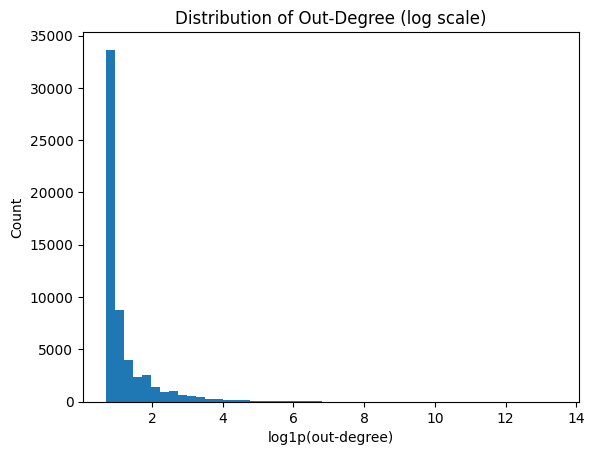

In [110]:
plt.hist(np.log1p(out_degree), bins=50)
plt.xlabel("log1p(out-degree)")
plt.ylabel("Count")
plt.title("Distribution of Out-Degree (log scale)")
plt.show()

In [111]:
# Check out degree of train users only.
train_users = set(data_train["user_hash"])
out_degree_train = social_graph.loc[social_graph["user_a"].isin(train_users), "user_a"].value_counts()
out_degree_train

user_a
d51101a4a32a81a9    5014
6ee13e7c11548663    2656
58fa05a73d77598b    2601
b7c36d74da29a69e    2224
2742824e355fe71d    2142
                    ... 
9c9c9cab24f50285       1
c4293bbbbb3fccff       1
09c0d8176748d9eb       1
0f25105b7af6e97d       1
9ca81007fd2f0489       1
Name: count, Length: 18696, dtype: int64

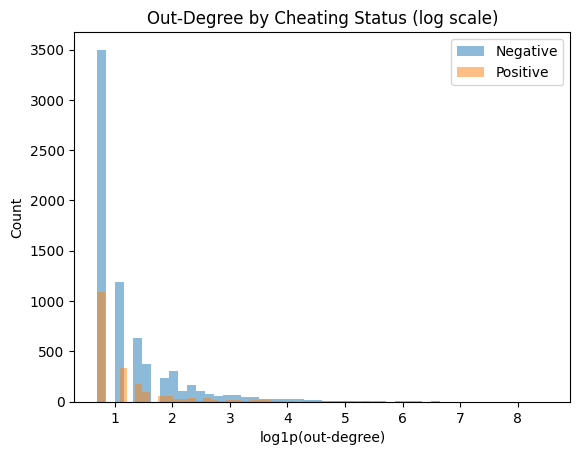

In [112]:
# Compare out-degree distributions between Positive and Negative training candidates.
positive_users = set(data_train.loc[target_train == 1, "user_hash"])
negative_users = set(data_train.loc[target_train == 0, "user_hash"])
labeled_users = positive_users | negative_users

out_degree_positive = out_degree_train[out_degree_train.index.isin(positive_users)]
out_degree_negative = out_degree_train[out_degree_train.index.isin(negative_users)]

plt.hist(np.log1p(out_degree_negative), bins=50, alpha=0.5, label="Negative")
plt.hist(np.log1p(out_degree_positive), bins=50, alpha=0.5, label="Positive")
plt.xlabel("log1p(out-degree)")
plt.ylabel("Count")
plt.title("Out-Degree by Cheating Status (log scale)")
plt.legend()
plt.show()

In [113]:
# Count referrers by their out-degree.
out_degree.value_counts().sort_index()

count
1         33643
2          8754
3          3991
4          2387
5          1519
          ...  
55134         1
81437         1
126114        1
152870        1
689094        1
Name: count, Length: 439, dtype: int64

**Findings.** Most referrers have very low out-degree: among 57,876 referrers, the median is 1 and the 75th percentile is 3. At the same time, the graph contains a small number of extreme referrers with tens or hundreds of thousands of outgoing edges, including one with 689,094. These extreme referrers do not appear among the training candidates and are therefore qualitatively different from the highly active candidates found in the training set, whose out-degree reaches 5,014. The latter may represent users who actively participate in recruiting in addition to being candidates, whereas the extreme ghost users may plausibly represent high-volume referral sources such as recruiting agencies or automated systems. The Positive counts are consistently lower than the Negative counts across the out-degree bins, in line with the overall class imbalance, with no apparent deviation in this pattern that would suggest an association between referral activity and cheating status. The frequency distribution further shows that most referrers have out-degree 1, with the number of referrers generally decreasing as out-degree increases.

### In-degree analysis

In [114]:
in_degree = social_graph["user_b"].value_counts()
in_degree

user_b
7a156a5d1ec7453c    4
7b1929bdd1a731e5    3
1e42564646803085    3
32fde464112043c0    3
0d1cdf27c450aa10    3
                   ..
c00d695618285cdd    1
547c2ea052c8a920    1
9e754ef84557fe16    1
1227d328fc5b0170    1
f2fc5659ff5aae58    1
Name: count, Length: 1710375, dtype: int64

In [115]:
# Count referrers by their in-degree.
in_degree.value_counts().sort_index()

count
1    1706006
2       4351
3         17
4          1
Name: count, dtype: int64

**Findings.** The in-degree distribution is unremarkable: almost all users receive only one or two incoming edges, and the maximum in-degree is 4. This contrasts sharply with the extreme out-degree values and is consistent with the expected structure of a referral graph, where individual users may receive only a small number of referrals while some referrers can generate many outgoing edges.

### Connected components

In [116]:
import networkx as nx

G = nx.Graph()

# Populate graph.
G.add_nodes_from(graph_users)
G.add_edges_from(graph_edges)

In [117]:
# Assign attributes to graph: in_train and label.
in_train = {user: 1 for user in train_users}
in_train.update({user: 0 for user in graph_users - train_users})

labels = dict(zip(
    data_train_in_graph["user_hash"],
    target_train_in_graph,
))

nx.set_node_attributes(G, in_train, "in_train")
nx.set_node_attributes(G, labels, "label")

In [118]:
# Calculate connected components.
components = list(nx.connected_components(G))

In [119]:
component_sizes = [len(component) for component in components]
component_df = pd.DataFrame({
    "component": range(len(components)),
    "size": [len(c) for c in components],
    "n_train": [len(c & train_users) for c in components],
    "n_labeled": [len(c & labeled_users) for c in components],
    "n_positive": [len(c & positive_users) for c in components],
    "n_negative": [len(c & negative_users) for c in components],
})

In [121]:
component_df.sort_values("size", ascending=False).head(20)

,component,size,n_train,n_labeled,n_positive,n_negative
0,0,1335750,144596,54230,11355,42875
5,5,98108,11603,5990,2133,3857
2,2,40308,5339,2646,874,1772
18,18,8451,996,769,302,467
25,25,7796,1432,499,46,453
1,1,6798,995,512,148,364
46,46,5797,956,529,155,374
6,6,4533,895,510,207,303
37,37,4204,461,373,182,191
16,16,4125,339,166,38,128


In [123]:
unreachable_components = component_df[component_df["n_labeled"] == 0]
n_unlabeled_unreachable = unreachable_components["n_train"].sum()
pct_unlabeled_unreachable = n_unlabeled_unreachable / len(train_users)
print(
    f"Unlabeled train users in graph but with no labeled "
    f"component-mates: {n_unlabeled_unreachable} "
    f"({pct_unlabeled_unreachable:.2%})"
)

Unlabeled train users in graph but with no labeled component-mates: 4048 (1.48%)


In [124]:
n_unlabeled_outside_graph = (
    (~data_train["user_hash"].isin(graph_users)) & data_train["is_cheating"].isna()
).sum()
n_unreachable_total = n_unlabeled_outside_graph + n_unlabeled_unreachable
pct_unreachable_total = n_unreachable_total / len(train_users)
print(
    f"Total unlabeled train users unreachable by propagation "
    f"(outside graph or in an unlabeled component): "
    f"{n_unreachable_total} ({pct_unreachable_total:.2%})"
)

Total unlabeled train users unreachable by propagation (outside graph or in an unlabeled component): 48134 (17.64%)


**Findings.** The social graph contains 17,624 connected components with a highly skewed size distribution: the largest component contains 1,335,750 nodes and the second-largest 98,108, followed by a long tail of smaller components. Most small components contain only a few nodes, with 10,681 components of size 2 and 2,583 of size 3.

Labeled users occur across many components, and class composition varies substantially between them. For example, the largest component contains 11,355 positive and 42,875 negative labeled users, while component 59 contains 957 positive and only 28 negative among its 985 labeled users.

This variation suggests that graph connectivity may carry information relevant to cheating status and motivates investigating label propagation. Components with few labeled users should be treated cautiously because their empirical class proportions are less reliable.

Among all train users, 44,086 (16.16%) are unlabeled and outside the graph, while a further 4,048 (1.48%) are unlabeled and belong to graph components containing no labeled training users. Thus, 48,134 unlabeled training users (17.64% of all train users) are unreachable by label propagation under the connected-component formulation. These users cannot receive labels from the graph and will require a separate strategy if the propagated labels are to be used to complete the training set.